# Семинар 2 — Геометрия позы камеры: от вращений к локальной оптимизации

**Зависимости блока:** `numpy`, `plotly`

**Сквозной вопрос семинара:** как описать положение и ориентацию камеры в 3D, а затем восстановить их по наблюдениям?

Сегодня нас интересует прежде всего **геометрия позы**. Подробную модель камеры, калибровку и алгоритмы PnP мы будем разбирать дальше по курсу.

---

## 0. Сквозная задача: 3D-сцена → изображение → поза камеры

Представим, что геометрия объекта в мировой системе координат известна. Для каждой точки

$$
X_w \in \mathbb{R}^3
$$

камера сначала выражает её в собственной системе координат:

$$
X_c = R X_w + t.
$$

Здесь

- $R$ задаёт **ориентацию** камеры относительно мировой системы координат;
- $t$ задаёт **сдвиг**;
- пара $(R,t)$ задаёт **позу камеры**.

После этого камера отображает $X_c$ в точку изображения. Пока обозначим эту операцию как готовую функцию

$$
z = \pi_K(X_c).
$$

Внутреннее устройство $\pi_K$ сегодня не является нашей основной темой: перспективную модель камеры и матрицу $K$ подробно разберём на следующей лекции.

Таким образом, **прямая задача** выглядит так:

$$
X_w
\;\longrightarrow\;
X_c = RX_w+t
\;\longrightarrow\;
z=\pi_K(X_c).
$$

А интересующая нас **обратная задача**:

> известны 3D-точки $X_i$ и места $z_i$, где камера наблюдает их на изображении;  
> как восстановить неизвестные $R$ и $t$?

Именно к этой задаче мы вернёмся в финале семинара.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

np.set_printoptions(precision=4, suppress=True)
pio.renderers.default = "plotly_mimetype+notebook"


In [ ]:
# Служебный код визуализации.
# На семинаре его внутреннюю реализацию разбирать не требуется:
# он нужен только для постановки сквозной задачи.

_HOUSE_POINTS = np.array([
    [-0.8, -0.6, 0.0],
    [ 0.8, -0.6, 0.0],
    [ 0.8,  0.6, 0.0],
    [-0.8,  0.6, 0.0],
    [-0.8, -0.6, 1.0],
    [ 0.8, -0.6, 1.0],
    [ 0.8,  0.6, 1.0],
    [-0.8,  0.6, 1.0],
    [ 0.0, -0.6, 1.55],
    [ 0.0,  0.6, 1.55],
], dtype=float)

_HOUSE_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7),
    (4, 8), (5, 8), (7, 9), (6, 9), (8, 9),
]


def _look_at_world_to_camera(camera_position, target):
    """Строит одну удобную для demo ориентацию камеры, смотрящей на target."""
    C = np.asarray(camera_position, dtype=float)
    target = np.asarray(target, dtype=float)
    world_up = np.array([0.0, 0.0, 1.0])

    z_cam = target - C
    z_cam /= np.linalg.norm(z_cam)

    x_cam = np.cross(world_up, z_cam)
    x_cam /= np.linalg.norm(x_cam)

    y_cam = np.cross(z_cam, x_cam)

    R_cw = np.vstack([x_cam, y_cam, z_cam])
    t_cw = -R_cw @ C
    return R_cw, t_cw


def _project_for_demo(X_world, R_cw, t_cw, K):
    X_cam = X_world @ R_cw.T + t_cw
    if np.any(X_cam[:, 2] <= 0):
        raise ValueError("Часть объекта оказалась позади камеры.")

    homogeneous_image = X_cam @ K.T
    uv = homogeneous_image[:, :2] / homogeneous_image[:, 2:3]
    return X_cam, uv


def _segments3d(points, edges):
    out = []
    for i, j in edges:
        out.extend([points[i], points[j], [np.nan, np.nan, np.nan]])
    return np.asarray(out, dtype=float)


def _segments2d(points, edges):
    out = []
    for i, j in edges:
        out.extend([points[i], points[j], [np.nan, np.nan]])
    return np.asarray(out, dtype=float)


def _camera_frustum_world(C, R_cw, K, image_size=(640, 480), depth=0.9):
    width, height = image_size
    corners_px = np.array([
        [0,     0,      1],
        [width, 0,      1],
        [width, height, 1],
        [0,     height, 1],
    ], dtype=float)

    rays_cam = corners_px @ np.linalg.inv(K).T
    rays_cam = rays_cam / rays_cam[:, 2:3] * depth

    # Для row-vector записи: camera -> world.
    return rays_cam @ R_cw + C


def show_forward_problem(
    camera_position=(3.2, -4.0, 2.6),
    look_at=(0.0, 0.0, 0.65),
    show_projection_rays=True,
):
    """Показывает одну и ту же сцену в world space и на изображении."""
    C = np.asarray(camera_position, dtype=float)
    target = np.asarray(look_at, dtype=float)

    R_cw, t_cw = _look_at_world_to_camera(C, target)

    # Для intro берём фиксированную простую pinhole-камеру.
    # Минус в fy нужен только для привычного направления pixel-v вниз.
    K = np.array([
        [500.0,    0.0, 320.0],
        [  0.0, -500.0, 240.0],
        [  0.0,    0.0,   1.0],
    ])

    _, uv = _project_for_demo(_HOUSE_POINTS, R_cw, t_cw, K)

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "xy"}]],
        column_widths=[0.58, 0.42],
        subplot_titles=(
            "Мировая сцена и произвольно ориентированная камера",
            "То, что наблюдает камера",
        ),
    )

    object_segments = _segments3d(_HOUSE_POINTS, _HOUSE_EDGES)
    fig.add_trace(
        go.Scatter3d(
            x=object_segments[:, 0],
            y=object_segments[:, 1],
            z=object_segments[:, 2],
            mode="lines",
            name="3D object",
            showlegend=False,
        ),
        row=1, col=1,
    )

    fig.add_trace(
        go.Scatter3d(
            x=_HOUSE_POINTS[:, 0],
            y=_HOUSE_POINTS[:, 1],
            z=_HOUSE_POINTS[:, 2],
            mode="markers+text",
            text=[f"P{i}" for i in range(len(_HOUSE_POINTS))],
            textposition="top center",
            name="3D points",
        ),
        row=1, col=1,
    )

    frustum = _camera_frustum_world(C, R_cw, K)
    frustum_segments = []
    for i in range(4):
        frustum_segments.extend([C, frustum[i], [np.nan, np.nan, np.nan]])
    for i in range(4):
        frustum_segments.extend([
            frustum[i],
            frustum[(i + 1) % 4],
            [np.nan, np.nan, np.nan],
        ])
    frustum_segments = np.asarray(frustum_segments, dtype=float)

    fig.add_trace(
        go.Scatter3d(
            x=frustum_segments[:, 0],
            y=frustum_segments[:, 1],
            z=frustum_segments[:, 2],
            mode="lines",
            name="camera frustum",
        ),
        row=1, col=1,
    )

    # Локальные оси камеры.
    axis_length = 0.7
    axes_world = C + (np.eye(3) * axis_length) @ R_cw
    for endpoint, label in zip(axes_world, ["x_c", "y_c", "z_c"]):
        fig.add_trace(
            go.Scatter3d(
                x=[C[0], endpoint[0]],
                y=[C[1], endpoint[1]],
                z=[C[2], endpoint[2]],
                mode="lines+text",
                text=["", label],
                showlegend=False,
                name=label,
            ),
            row=1, col=1,
        )

    if show_projection_rays:
        for idx in [0, 2, 6, 8]:
            p = _HOUSE_POINTS[idx]
            fig.add_trace(
                go.Scatter3d(
                    x=[C[0], p[0]],
                    y=[C[1], p[1]],
                    z=[C[2], p[2]],
                    mode="lines",
                    opacity=0.35,
                    showlegend=False,
                ),
                row=1, col=1,
            )

    image_segments = _segments2d(uv, _HOUSE_EDGES)

    fig.add_trace(
        go.Scatter(
            x=image_segments[:, 0],
            y=image_segments[:, 1],
            mode="lines",
            showlegend=False,
            name="projection",
        ),
        row=1, col=2,
    )

    fig.add_trace(
        go.Scatter(
            x=uv[:, 0],
            y=uv[:, 1],
            mode="markers+text",
            text=[f"P{i}" for i in range(len(uv))],
            textposition="top center",
            showlegend=False,
            name="image points",
        ),
        row=1, col=2,
    )

    fig.update_scenes(
        aspectmode="data",
        xaxis_title="X_w",
        yaxis_title="Y_w",
        zaxis_title="Z_w",
    )
    fig.update_xaxes(title_text="u [px]", range=[0, 640], row=1, col=2)
    fig.update_yaxes(
        title_text="v [px]",
        range=[480, 0],
        scaleanchor="x2",
        scaleratio=1,
        row=1, col=2,
    )
    fig.update_layout(
        width=1150,
        height=620,
        margin=dict(l=20, r=20, t=70, b=20),
    )

    fig.show()
    return R_cw, t_cw

In [ ]:
np.asarray(_HOUSE_POINTS).shape

### Посмотрим на прямую задачу

Слева — одна и та же 3D-сцена в мировой системе координат и камера со своей локальной системой координат $x_c,y_c,z_c$.

Справа — 2D-наблюдение этой сцены.

Линии от камеры к нескольким вершинам нужны только для геометрической интуиции: одна 3D-точка задаёт один луч через центр проекции и одну точку изображения.

> **Перед запуском:** как изменится изображение, если камера переместится вправо?  
> А если оставить центр камеры на месте, но изменить её ориентацию?

In [ ]:
# Единственная ячейка Block 0, с которой предлагается немного поэкспериментировать.
# Измените CAMERA_POSITION и перезапустите ячейку.

CAMERA_POSITION = (5, -4.0, 0)
LOOK_AT = (0.0, 0.5, 0.65)

R_demo, t_demo = show_forward_problem(
    camera_position=CAMERA_POSITION,
    look_at=LOOK_AT,
)

print("R =")
print(R_demo)
print("\nt =", t_demo)


### Что нам понадобится дальше?

На этом этапе не нужно уметь вычислять проекцию камеры вручную. Для дальнейшего семинара достаточно заметить три вещи.

1. **Поза камеры состоит из двух разных частей:** ориентации $R$ и сдвига $t$.
2. Изменение $R$ меняет положение локальных осей камеры и, следовательно, всё изображение.
3. В обратной задаче $R$ и $t$ неизвестны — их надо подобрать так, чтобы предсказанные 2D-точки совпали с наблюдаемыми.

Начнём с наиболее нетривиальной части: **что вообще является допустимым вращением $R$?**

Иными словами, если взять произвольную матрицу $3\times3$, будет ли она корректно описывать поворот пространства?

> **Справочная иллюстрация:** формальная схема pinhole-камеры хорошо показана в  
> Stanford CS231A, *Course Notes 1: Camera Models*, Figure 2:  
> https://web.stanford.edu/class/cs231a/course_notes/01-camera-models.pdf
>
> Подробно эту модель сейчас не выводим: здесь она нужна как пример задачи, в которой геометрия позы становится практически полезной.

## 1. Какие матрицы действительно задают вращение?

**Зависимости блока:** `numpy`, `plotly`

В предыдущем блоке мы использовали некоторую матрицу $R$ для изменения ориентации камеры:


$$
X_c = RX_w + t.
$$

Но произвольная матрица $3\times3$ вращением не является.

Попробуем получить ограничения на $R$ не из определения группы, а из простого геометрического требования:

> **поворот не должен менять расстояния между точками.**

Пусть две точки имеют координаты $x$ и $y$. Вектор между ними

$$
d=x-y.
$$

После применения линейного преобразования $R$:

$$
d' = Rd.
$$

Для вращения должно выполняться

$$
\|Rd\|=\|d\|
$$

для любого $d\in\mathbb{R}^3$. Возведём обе части в квадрат:

$$
(Rd)^T(Rd)=d^Td,
$$

$$
d^TR^TRd=d^Td.
$$

Так как это равенство должно выполняться для **любого** $d$,

$$
\boxed{R^TR=I}.
$$

Матрицы с таким свойством называются **ортогональными**.

### Почему ещё нужно условие $\det R=+1$?

Из

$$
R^TR=I
$$

следует

$$
\det(R)^2=1,
$$

поэтому у ортогональной матрицы возможны два случая:

$$
\det R=+1
\qquad\text{или}\qquad
\det R=-1.
$$

Это **не** означает, что одно и то же вращение описывается двумя матрицами.  
Для rotation matrix в $SO(3)$ представление однозначно. Здесь логика другая:

- $\det R=+1$ — **собственные вращения** (*proper rotations*);
- $\det R=-1$ — **отражения** или отражение в сочетании с вращением (*improper rotations*).

Если смотреть на базис, то при $\det R=+1$ правая система координат остаётся правой, а при $\det R=-1$ ориентация меняется на противоположную.

Поэтому множество собственно вращений — это

$$
\boxed{
SO(3)=\{R\in\mathbb{R}^{3\times3}:R^TR=I,\ \det R=1\}.
}
$$

### Сколько у вращения степеней свободы (Degrees of Freedom / DoF)?

Матрица $3\times3$ содержит 9 чисел.

Но условие

$$
R^TR=I
$$

задаёт 6 независимых ограничений:

- три столбца должны иметь единичную длину;
- три пары различных столбцов должны быть ортогональны.

Поэтому локально остаётся

$$
9-6=3
$$

степени свободы.

Условие $\det R=+1$ не отнимает ещё одну степень свободы: оно просто выбирает одну из двух компонент множества ортогональных матриц — вращения вместо отражений.

Итак,

$$
\boxed{\dim SO(3)=3}.
$$

Это сразу порождает естественный вопрос:

> если вращение имеет всего 3 DoF, зачем хранить 9 чисел с ограничениями? Нельзя ли описать его просто тремя числами?

### Визуально: вращение vs отражение

Возьмём максимально простой асимметричный объект — **домик**, заданный вершинами и рёбрами в собственной системе координат.

Его локальная система координат совпадает с мировой в начальном положении, а начало координат (origin) находится внутри домика.

В следующей визуализации:

- сначала показан исходный объект;
- затем результаты двух вращений $R_1$ и $R_2$;
- отдельно — отражение, получаемое действием матрицы $M$:

$$
M=\operatorname{diag}(1,1,-1).
$$

Во всех случаях применяется одно и то же линейное преобразование ко всем точкам:

$$
x' = Mx.
$$

И вращения, и отражение сохраняют длины. Но только у вращений

$$
\det R=+1.
$$

У отражения

$$
\det M=-1,
$$

поэтому оно меняет ориентацию системы координат.

In [ ]:
def rot_x(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rot_y(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [ c, 0.0,  s],
        [0.0, 1.0, 0.0],
        [-s, 0.0,  c],
    ])


def rot_z(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [ c, -s, 0.0],
        [ s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


# Wireframe-домик. Origin выбран внутри объекта.
HOUSE_POINTS = np.array([
    [-0.8, -0.6, -0.6],
    [ 0.8, -0.6, -0.6],
    [ 0.8,  0.6, -0.6],
    [-0.8,  0.6, -0.6],

    [-0.8, -0.6,  0.35],
    [ 0.8, -0.6,  0.35],
    [ 0.8,  0.6,  0.35],
    [-0.8,  0.6,  0.35],

    [ 0.0, -0.6,  1.05],
    [ 0.0,  0.6,  1.05],
], dtype=float)

HOUSE_EDGES = [
    # нижний прямоугольник
    (0, 1), (1, 2), (2, 3), (3, 0),

    # стены
    (0, 4), (1, 5), (2, 6), (3, 7),

    # верх стен
    (4, 5), (5, 6), (6, 7), (7, 4),

    # крыша
    (4, 8), (5, 8),
    (7, 9), (6, 9),
    (8, 9),
]


def matrix_diagnostics(M):
    return {
        "orth_error": np.linalg.norm(M.T @ M - np.eye(3)),
        "det": np.linalg.det(M),
    }


def add_frame(fig, origin, basis=np.eye(3), axis_length=0.65, row=1, col=1, prefix=""):
    """Рисует тройку локальных осей. Столбцы basis — направления осей."""
    origin = np.asarray(origin, dtype=float)

    for i, label in enumerate(["x", "y", "z"]):
        endpoint = origin + axis_length * basis[:, i]
        fig.add_trace(
            go.Scatter3d(
                x=[origin[0], endpoint[0]],
                y=[origin[1], endpoint[1]],
                z=[origin[2], endpoint[2]],
                mode="lines+text",
                text=["", f"{prefix}{label}"],
                textposition="top center",
                showlegend=False,
                hoverinfo="skip",
            ),
            row=row,
            col=col,
        )


def add_axis_through_origin(fig, axis, label, row=1, col=1, length=1.35):
    """Рисует прямую через origin в направлении axis."""
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)

    p1 = -length * axis
    p2 =  length * axis

    fig.add_trace(
        go.Scatter3d(
            x=[p1[0], p2[0]],
            y=[p1[1], p2[1]],
            z=[p1[2], p2[2]],
            mode="lines+text",
            text=["", label],
            textposition="top center",
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row,
        col=col,
    )


def house_segments(points):
    """Преобразует вершины домика в последовательность сегментов для Scatter3d."""
    segments = []
    for i, j in HOUSE_EDGES:
        segments.extend([
            points[i],
            points[j],
            [np.nan, np.nan, np.nan],
        ])
    return np.asarray(segments, dtype=float)


def add_house(fig, M, row=1, col=1, draw_axis=True):
    """Применяет M к домику; draw_axis управляет отображением локальных осей объекта."""

    # Вопрос: в формулах мы пишем x' = Mx. Почему здесь появляется M.T?
    points = HOUSE_POINTS @ M.T
    segments = house_segments(points)

    fig.add_trace(
        go.Scatter3d(
            x=segments[:, 0],
            y=segments[:, 1],
            z=segments[:, 2],
            mode="lines",
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row,
        col=col,
    )

    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=3),
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row,
        col=col,
    )

    # Тот же оператор действует и на локальный базис объекта.
    if draw_axis:
        add_frame(fig, np.zeros(3), M, row=row, col=col, prefix="o_")


def set_scene_equal(fig, scene_name, lim=1.7):
    fig.layout[scene_name].update(
        aspectmode="cube",
        xaxis=dict(range=[-lim, lim], title="X_w"),
        yaxis=dict(range=[-lim, lim], title="Y_w"),
        zaxis=dict(range=[-lim, lim], title="Z_w"),
    )


ANGLE_1 = np.radians(55)
ANGLE_2 = np.radians(75)

R1 = rot_z(ANGLE_1)
R2 = rot_x(ANGLE_2)

M_reflect = np.diag([1.0, 1.0, -1.0])

for name, M in [("R1", R1), ("R2", R2), ("Reflection M", M_reflect)]:
    d = matrix_diagnostics(M)
    print(
        f"{name:12s} | "
        f"||M^T M-I|| = {d['orth_error']:.6f} | "
        f"det = {d['det']:.6f}"
    )

In [ ]:
transforms = [
    ("Исходный домик", np.eye(3)),
    ("R1: rotation", R1),
    ("R2: rotation", R2),
    ("M: reflection", M_reflect),
]

fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{"type": "scene"}, {"type": "scene"}],
        [{"type": "scene"}, {"type": "scene"}],
    ],
    subplot_titles=[title for title, _ in transforms],
)

scene_names = ["scene", "scene2", "scene3", "scene4"]

for idx, ((title, M), scene_name) in enumerate(zip(transforms, scene_names), start=1):
    row = 1 if idx <= 2 else 2
    col = 1 if idx % 2 == 1 else 2

    add_house(fig, M, row=row, col=col)
    set_scene_equal(fig, scene_name)

fig.update_layout(
    width=1050,
    height=850,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()

### Является ли множество вращений линейным пространством?

Матрицы вращения можно складывать как обычные матрицы. Однако это ещё не означает, что результат снова будет вращением.

Проверим два разных способа объединить два вращения:

1. обычное среднее матриц

$$
A=\frac{R_1+R_2}{2},
$$

2. композицию преобразований

$$
R_{\mathrm{comp}}=R_2R_1.
$$

Для корректного вращения локальные оси объекта должны оставаться ортонормированными.

Перед запуском попробуйте предсказать:

- что произойдёт с формой домика после применения $A$?
- останутся ли его локальные оси взаимно перпендикулярными?
- что произойдёт после композиции $R_2R_1$?

In [ ]:
A = 0.5 * (R1 + R2)
R_comp = R2 @ R1

for name, M in [("R1", R1), ("R2", R2), ("(R1+R2)/2", A), ("R2 @ R1", R_comp)]:
    d = matrix_diagnostics(M)
    print(
        f"{name:12s} | "
        f"||M^T M-I|| = {d['orth_error']:.6f} | "
        f"det = {d['det']:.6f}"
    )

In [ ]:
variants = [
    ("Исходный домик", np.eye(3)),
    ("(R1+R2)/2: не rotation", A),
    ("R2 @ R1: композиция", R_comp),
]

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[title for title, _ in variants],
)

for col, (title, M) in enumerate(variants, start=1):
    add_house(fig, M, row=1, col=col)

for scene_name in ["scene", "scene2", "scene3"]:
    set_scene_equal(fig, scene_name)

fig.update_layout(
    width=1300,
    height=460,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()

In [ ]:
(R2 @ R1), (R1 @ R2)

### Что произошло?

Для $R_1$ и композиции $R_2R_1$:

$$
M^TM=I,\qquad \det M=1.
$$

Домик меняет ориентацию, но сохраняет свою форму, а его локальные оси остаются ортонормированными.

Для

$$
A=\frac{R_1+R_2}{2}
$$

это уже неверно:

$$
A^TA\neq I.
$$

Поэтому $A$ деформирует объект, а преобразованные локальные оси перестают образовывать ортонормированный базис.

Следовательно,

$$
R_1,R_2\in SO(3)
\quad\not\Rightarrow\quad
R_1+R_2\in SO(3).
$$

То есть $SO(3)$ **не является линейным подпространством** пространства всех матриц $3\times3$.

Зато композиция вращений снова является вращением:

$$
R_1,R_2\in SO(3)
\Rightarrow
R_2R_1\in SO(3).
$$

Кроме того:

- единичная матрица $I$ — вращение;
- для каждого $R$ существует обратное вращение

$$
R^{-1}=R^T;
$$

- умножение матриц ассоциативно.

Поэтому вращения образуют **группу относительно композиции**:

$$
\boxed{SO(3)\text{ — группа вращений в }\mathbb{R}^3.}
$$

Практическая мысль:

> **естественная операция над вращениями — не сложение матриц, а композиция преобразований.**

Следующий шаг: раз у вращения всего 3 DoF, попробуем всё-таки задать его тремя числами — углами Эйлера — и посмотрим, какую цену мы за это платим.

## 2. Три числа для вращения: углы Эйлера и gimbal lock (складывание рамок)

**Зависимости блока:** `numpy`, `plotly`

Мы выяснили, что

$$
\dim SO(3)=3.
$$

Поэтому естественная идея — вместо девяти элементов матрицы $R$ хранить ровно три числа.

Один из самых интуитивных способов — представить ориентацию как последовательность трёх поворотов вокруг координатных осей. Это и есть **углы Эйлера** в широком практическом смысле.

Важно: одной фразы «углы Эйлера» недостаточно. Нужно всегда фиксировать порядок осей и convention. В этом семинаре используем одну конкретную convention и дальше её не меняем.

### Наша convention: ZYX (yaw–pitch–roll)

Будем использовать **активные вращения**, column vectors и распространённую
yaw–pitch–roll convention **intrinsic ZYX**:

1. yaw $\psi$ — вокруг текущей оси $z$ тела (рыскание);
2. pitch $\theta$ — вокруг уже повернувшейся оси $y'$ (тангаж);
3. roll $\phi$ — вокруг ещё раз повернувшейся оси $x''$ (крен).

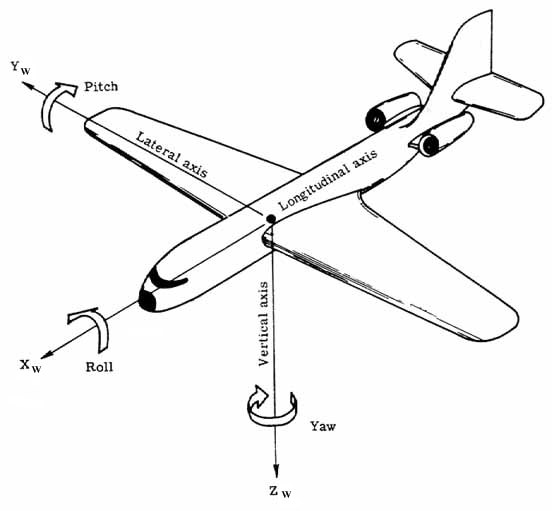

Чтобы не путать сторону умножения, временно обозначим текущую ориентацию
СК тела относительно мировых координат через $Q$:

$$
\boxed{x_w = Qx_b}.
$$

То есть столбцы $Q$ — это направления осей тела, выраженные в world coordinates.

Элементарные матрицы поворота:

$$
R_x(\phi)=
\begin{bmatrix}
1&0&0\\
0&\cos\phi&-\sin\phi\\
0&\sin\phi&\cos\phi
\end{bmatrix},
$$

$$
R_y(\theta)=
\begin{bmatrix}
\cos\theta&0&\sin\theta\\
0&1&0\\
-\sin\theta&0&\cos\theta
\end{bmatrix},
$$

$$
R_z(\psi)=
\begin{bmatrix}
\cos\psi&-\sin\psi&0\\
\sin\psi&\cos\psi&0\\
0&0&1
\end{bmatrix}.
$$

Другие Euler conventions не «неправильные»: нужно просто явно фиксировать
порядок осей и то, являются они moving/body или fixed/world axes.

### Почему поворот вокруг собственной оси домножается справа?

Это можно вывести прямо из

$$
x_w=Qx_b.
$$

Пусть малый или конечный дополнительный поворот $\Delta R$ задан
**в координатах тела**. Тогда сначала меняются body coordinates:

$$
x_b'=\Delta R\,x_b.
$$

Переводим результат в world coordinates:

$$
x_w'
=
Qx_b'
=
Q\Delta R\,x_b.
$$

Следовательно,

$$
\boxed{Q_{\text{new}}=Q_{\text{old}}\Delta R}.
$$

То есть поворот вокруг **оси, неподвижной относительно тела** (внутренней оси) добавляется **справа**.

Если же $\Delta R$ задан относительно неподвижной **мировой оси**, то он
действует уже на мировой вектор:

$$
x_w'
=
\Delta R\,x_w
=
\Delta RQx_b,
$$

поэтому

$$
\boxed{Q_{\text{new}}=\Delta RQ_{\text{old}}}.
$$

То есть поворот вокруг **неподвижной/мировой оси** добавляется **слева**.

Это полезное правило не нужно запоминать отдельно: обе стороны умножения
следуют непосредственно из того, в какой системе координат задан дополнительный поворот.

### Одна конечная ориентация — две эквивалентные интерпретации

Теперь применим это правило к yaw–pitch–roll.

Для **intrinsic ZYX** (внутренние ZYX) начинаем с $Q_0=I$ и каждый раз вращаемся вокруг
текущих осей тела, поэтому домножаем справа:

$$
Q_0=I,
$$

$$
Q_1=R_z(\psi),
$$

$$
Q_2=R_z(\psi)R_y(\theta),
$$

$$
\boxed{
Q_3=R_z(\psi)R_y(\theta)R_x(\phi)
}.
$$

Ту же конечную ориентацию можно получить вращениями вокруг **неподвижных
мировых осей**, но уже в обратном порядке — **внешние XYZ**:

$$
Q_0=I,
$$

$$
Q_1=R_x(\phi),
$$

$$
Q_2=R_y(\theta)R_x(\phi),
$$

$$
\boxed{
Q_3=R_z(\psi)R_y(\theta)R_x(\phi)
}.
$$

Итого:

$$
\boxed{
\text{intrinsic ZYX}
\equiv
\text{extrinsic XYZ}
}
$$

для одной и той же конечной orientation.

Важно: **промежуточные ориентации различаются**, совпадает только итоговая матрица.

| Интерпретация | Последовательность | Update |
|---|---|---|
| движущиеся оси тела | yaw $z$ $\to$ pitch $y'$ $\to$ roll $x''$ | $Q_{\rm new}=Q_{\rm old}\Delta R$ |
| неподвижные мировые оси | roll $x$ $\to$ pitch $y$ $\to$ yaw $z$ | $Q_{\rm new}=\Delta RQ_{\rm old}$ |

Следующая визуализация показывает обе последовательности на одном и том же домике.

In [ ]:
# Одни и те же углы для двух эквивалентных последовательностей.
yaw = np.radians(45)
pitch = np.radians(40)
roll = np.radians(30)

# intrinsic ZYX: moving/body axes -> right multiplication
Q_intrinsic = [
    np.eye(3),
    rot_z(yaw),
    rot_z(yaw) @ rot_y(pitch),
    rot_z(yaw) @ rot_y(pitch) @ rot_x(roll),
]

# extrinsic XYZ: fixed/world axes -> left multiplication
Q_extrinsic = [
    np.eye(3),
    rot_x(roll),
    rot_y(pitch) @ rot_x(roll),
    rot_z(yaw) @ rot_y(pitch) @ rot_x(roll),
]

titles_top = [
    "initial",
    "yaw about body z",
    "pitch about body y′",
    "roll about body x″",
]
titles_bottom = [
    "initial",
    "roll about world x",
    "pitch about world y",
    "yaw about world z",
]

fig = make_subplots(
    rows=2,
    cols=4,
    specs=[
        [{"type": "scene"}] * 4,
        [{"type": "scene"}] * 4,
    ],
    subplot_titles=titles_top + titles_bottom,
    vertical_spacing=0.06,
)

# Верхний ряд: intrinsic ZYX.
for col, Q in enumerate(Q_intrinsic, start=1):
    add_house(fig, Q, row=1, col=col)

    # Неподвижный world frame — ориентир.
    add_frame(
        fig,
        np.zeros(3),
        np.eye(3),
        axis_length=0.9,
        row=1,
        col=col,
        prefix="w_",
    )

# Нижний ряд: extrinsic XYZ.
for col, Q in enumerate(Q_extrinsic, start=1):
    add_house(fig, Q, row=2, col=col)
    add_frame(
        fig,
        np.zeros(3),
        np.eye(3),
        axis_length=0.9,
        row=2,
        col=col,
        prefix="w_",
    )

for i in range(1, 9):
    scene_name = "scene" if i == 1 else f"scene{i}"
    set_scene_equal(fig, scene_name, lim=1.65)

fig.update_layout(
    width=1450,
    height=780,
    margin=dict(l=10, r=10, t=80, b=10),
)
fig.show()

print(
    "Финальные матрицы совпадают:",
    np.allclose(Q_intrinsic[-1], Q_extrinsic[-1]),
)
print(
    "||Q_intrinsic - Q_extrinsic||_F =",
    np.linalg.norm(Q_intrinsic[-1] - Q_extrinsic[-1]),
)

В обоих рядах последняя ориентация одинакова:

$$
Q_{\text{intrinsic}}
=
Q_{\text{extrinsic}}
=
R_z(\psi)R_y(\theta)R_x(\phi).
$$

Но теперь особенно важно не читать произведение

$$
R_zR_yR_x
$$

как простой список действий «слева направо».

- Для **intrinsic ZYX** это yaw $\to$ pitch $\to$ roll вокруг **движущихся** осей.
- Если те же матрицы читать как rotations вокруг **фиксированных мировых осей**,
  действия идут справа налево: roll $\to$ pitch $\to$ yaw.

Именно moving-axis интерпретация особенно удобна, чтобы увидеть,
что происходит при gimbal lock.

In [ ]:
def R_zyx(yaw, pitch, roll):
    """Final orientation for intrinsic ZYX = extrinsic XYZ."""
    return rot_z(yaw) @ rot_y(pitch) @ rot_x(roll)


# Hands-on: поменяйте три угла и посмотрите на ориентацию домика.
YAW_DEG = 80
PITCH_DEG = 25
ROLL_DEG = -20

R_euler = R_zyx(
    np.radians(YAW_DEG),
    np.radians(PITCH_DEG),
    np.radians(ROLL_DEG),
)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[
        "Исходная ориентация",
        f"yaw={YAW_DEG}°, pitch={PITCH_DEG}°, roll={ROLL_DEG}°",
    ],
)
add_house(fig, np.eye(3), row=1, col=1)
add_house(fig, R_euler, row=1, col=2)
set_scene_equal(fig, "scene")
set_scene_equal(fig, "scene2")
fig.update_layout(width=1000, height=470, margin=dict(l=10, r=10, t=70, b=10))
fig.show()

print("R =")
print(R_euler)
print("\nR^T R =")
print(R_euler.T @ R_euler)
print("\ndet(R) =", np.linalg.det(R_euler))

### Где возникает проблема?

Физическая модель с тремя карданными рамками хорошо показывает источник проблемы:

![Gimbal lock animation](https://upload.wikimedia.org/wikipedia/commons/4/49/Gimbal_Lock_Plane.gif)

*Источник: Wikimedia Commons, “Gimbal Lock Plane.gif”, Drummyfish, CC0.*

Теперь рассмотрим именно **intrinsic ZYX**. Оси последовательных moving/body rotations, выраженные в world coordinates, можно записать так:

$$
a_{\mathrm{yaw}}=e_z,
$$

$$
a_{\mathrm{pitch}}=R_z(\psi)e_y,
$$

$$
a_{\mathrm{roll}}=R_z(\psi)R_y(\theta)e_x.
$$

Для вращения вокруг оси $y$ используем

$$
R_y(\theta)=
\begin{bmatrix}
\cos\theta & 0 & \sin\theta\\
0 & 1 & 0\\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}.
$$

Так как

$$
e_x=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
$$

то

$$
R_y(\theta)e_x
=
\begin{bmatrix}
\cos\theta\\
0\\
-\sin\theta
\end{bmatrix}.
$$


При $\theta=90^\circ$ имеем $\cos\theta=0$ и $\sin\theta=1$, поэтому

$$
R_y(90^\circ)e_x
=
\begin{bmatrix}
0\\
0\\
-1
\end{bmatrix}
=
-e_z.
$$

Остаётся применить предшествующий yaw:

$$
a_{\mathrm{roll}}
=
R_z(\psi)R_y(90^\circ)e_x
=
R_z(\psi)(-e_z).
$$

Но вращение вокруг оси $z$ не изменяет саму ось $z$:

$$
R_z(\psi)e_z=e_z.
$$

Следовательно,

$$
\boxed{
a_{\mathrm{roll}}=-e_z.
}
$$

То есть yaw- и roll-оси становятся **коллинеарны**: две управляющие координаты пытаются вращать вокруг одной и той же геометрической оси.

Это и есть **gimbal lock**.

In [ ]:
def add_axis_line(fig, axis, label, row, col, length=1.2):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    endpoint = length * axis
    fig.add_trace(
        go.Scatter3d(
            x=[0.0, endpoint[0]], y=[0.0, endpoint[1]], z=[0.0, endpoint[2]],
            mode="lines+text", text=["", label], textposition="top center",
            showlegend=False, hoverinfo="skip",
        ),
        row=row, col=col,
    )


def gimbal_axes_zyx(yaw, pitch):
    e_x = np.array([1.0, 0.0, 0.0])
    e_y = np.array([0.0, 1.0, 0.0])
    e_z = np.array([0.0, 0.0, 1.0])
    yaw_axis = e_z
    pitch_axis = rot_z(yaw) @ e_y
    roll_axis = rot_z(yaw) @ rot_y(pitch) @ e_x
    return yaw_axis, pitch_axis, roll_axis


YAW = np.radians(0)
ROLL = np.radians(30)
cases = [
    ("pitch = 30°", np.radians(30)),
    ("pitch = 90° — gimbal lock", np.radians(90)),
]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[title for title, _ in cases],
)

for col, (title, pitch) in enumerate(cases, start=1):
    R = R_zyx(YAW, pitch, ROLL)
    add_house(fig, R, row=1, col=col)
    yaw_axis, pitch_axis, roll_axis = gimbal_axes_zyx(YAW, pitch)
    add_axis_line(fig, yaw_axis, "yaw axis", 1, col)
    add_axis_line(fig, pitch_axis, "pitch axis", 1, col)
    add_axis_line(fig, roll_axis, "roll axis", 1, col)
    print(f"{title:27s} | <yaw, roll> = {np.dot(yaw_axis, roll_axis): .6f}")

set_scene_equal(fig, "scene")
set_scene_equal(fig, "scene2")
fig.update_layout(width=1050, height=500, margin=dict(l=10, r=10, t=70, b=10))
fig.show()

### Математически теряется не степень свободы вращения, а степень свободы координат

Само пространство вращений при pitch $=90^\circ$ никуда не «схлопывается»:

$$
\dim SO(3)=3
$$

остаётся верным.

Ломается именно отображение

$$
(\psi,\theta,\phi)\longmapsto R(\psi,\theta,\phi).
$$

Подставим $\theta=\pi/2$. Тогда

$$
R\left(\psi,\frac{\pi}{2},\phi\right)=
\begin{bmatrix}
0&-\sin(\psi-\phi)&\cos(\psi-\phi)\\
0&\cos(\psi-\phi)&\sin(\psi-\phi)\\
-1&0&0
\end{bmatrix}.
$$

Отдельно $\psi$ и $\phi$ больше не появляются. Матрица зависит только от

$$
\boxed{\psi-\phi}.
$$

Поэтому бесконечно много разных троек Euler angles задают **одно и то же вращение**.

In [ ]:
pitch_lock = np.pi / 2
angle_sets = [
    (0.2, pitch_lock, 0.0),
    (0.0, pitch_lock, -0.2),
    (0.7, pitch_lock, 0.5),
]
rotations = [R_zyx(*angles) for angles in angle_sets]

for i, angles in enumerate(angle_sets):
    yaw, pitch, roll = angles
    print(
        f"set {i}: yaw={yaw:+.2f}, pitch={np.degrees(pitch):.1f}°, "
        f"roll={roll:+.2f}, yaw-roll={yaw-roll:+.2f}"
    )

print()
print("R0 == R1:", np.allclose(rotations[0], rotations[1], atol=1e-12))
print("R0 == R2:", np.allclose(rotations[0], rotations[2], atol=1e-12))

### Как увидеть потерю локального направления без готового якобиана?

При gimbal lock матрица зависит от $\psi-\phi$.

Значит совместное малое изменение

$$
\psi\leftarrow\psi+\varepsilon,
\qquad
\phi\leftarrow\phi+\varepsilon
$$

не меняет разность $\psi-\phi$.

В точке $\theta=90^\circ$ такое изменение Euler-параметров вообще перестаёт менять вращение.

Посмотрим, насколько сильно меняется матрица вдоль этого направления при приближении к singularity.

In [ ]:
yaw0 = 0.4
roll0 = -0.3
eps = 1e-6

pitch_values = np.linspace(0.0, np.pi / 2, 300)
responses = []
for pitch in pitch_values:
    R0 = R_zyx(yaw0, pitch, roll0)
    R1_eps = R_zyx(yaw0 + eps, pitch, roll0 + eps)
    responses.append(np.linalg.norm(R1_eps - R0, ord="fro") / eps)
responses = np.asarray(responses)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.degrees(pitch_values), y=responses, mode="lines", name="sensitivity"))
fig.update_layout(
    title="Одно направление Euler-параметров становится невидимым",
    xaxis_title="pitch θ, degrees",
    yaxis_title="||ΔR||_F / ε",
    width=850,
    height=430,
)
fig.show()

for pitch_deg in [0, 60, 80, 89, 90]:
    pitch = np.radians(pitch_deg)
    R0 = R_zyx(yaw0, pitch, roll0)
    R1_eps = R_zyx(yaw0 + eps, pitch, roll0 + eps)
    response = np.linalg.norm(R1_eps - R0, ord="fro") / eps
    print(f"pitch={pitch_deg:2d}° -> sensitivity={response:.8f}")

### Связь с якобианом

Полный локальный якобиан параметризации можно записать как

$$
J_E=\frac{\partial\,\operatorname{vec}R}{\partial(\psi,\theta,\phi)}\in\mathbb{R}^{9\times3}.
$$

В обычной точке три малых изменения углов Эйлера дают три независимых направления изменения $R$, поэтому

$$
\operatorname{rank}J_E=3.
$$

При $\theta=\pm90^\circ$ существует ненулевое изменение параметров, которое в первом порядке вообще не меняет $R$. Значит у якобиана появляется null direction и

$$
\boxed{\operatorname{rank}J_E=2}.
$$

Именно это численно можно обнаружить через минимальное сингулярное число:

$$
\sigma_{\min}(J_E)\to0.
$$

На семинаре общий якобиан намеренно не реализуем: здесь важнее понять, **почему** он должен потерять ранг.

### Что мы получили?

Углы Эйлера обладают очень привлекательными свойствами:

- ровно 3 числа для 3 степенях свободы;
- простая физическая интерпретация;
- легко задавать ориентацию человеку.

Но цена минимальной глобальной параметризации:

- зависимость от convention;
- неоднозначная параметризация: разные наборы углов могут задавать одно вращение;
- существуют сингулярные конфигурации — **gimbal lock**;
- около сингулярности малые изменения параметров плохо соответствуют геометрически независимым изменениям вращения.

Ключевой вывод:

> **gimbal lock — не особая или вырожденная ориентация в $SO(3)$. Это вырождение выбранной системы координат на $SO(3)$.**

Следующий вопрос:

> существуют ли другие способы хранить вращение, у которых нет Euler-gimbal-lock, и обязательно ли вообще искать одну глобальную тройку координат для всего $SO(3)$?

## 3. Кватернионы: убрать gimbal lock, не убирая геометрию

**Зависимости блока:** `numpy`, `plotly`  
**Новых Python-пакетов нет.**

В параметризации углами Эйлера мы пытались описать всё пространство вращений ровно тремя
глобальными координатами. Результат оказался удобным, но у такой системы
координат появились особые точки.

Один из самых распространённых альтернативных способов **хранить**
ориентацию — единичный кватернион

$$
q=(w,\mathbf v)=(w,x,y,z)\in\mathbb R^4,
\qquad
\|q\|=1.
$$

То есть кватернион использует **4 числа + 1 ограничение**, и потому снова
имеет 3 степени свободы:

$$
q\in S^3\subset\mathbb R^4,
\qquad
\dim S^3=3.
$$

Связь с уже знакомым представлением «ось + угол» особенно проста.
Вращению на угол $\theta$ вокруг единичной оси $\mathbf u$ соответствует

$$
\boxed{
q=
\left(
\cos\frac{\theta}{2},
\;
\mathbf u\sin\frac{\theta}{2}
\right).
}
$$

![Axis-angle representation](https://commons.wikimedia.org/wiki/Special:Redirect/file/Euler_AxisAngle.svg)

*Справочная иллюстрация axis–angle: Wikimedia Commons, “Euler AxisAngle.svg”, CC0.*

Кватернион можно рассматривать как оператор вращения: если
$\tilde{\mathbf x}=(0,\mathbf x)$ — «чистый» кватернион, то

$$
\tilde{\mathbf x}'
=
q\,\tilde{\mathbf x}\,q^{-1}.
$$

А произведение кватернионов соответствует композиции вращений. Если

$$
q_1=(w_1,\mathbf v_1),
\qquad
q_2=(w_2,\mathbf v_2),
$$

то произведение Гамильтона в векторной записи имеет вид

$$
\boxed{
q_1\otimes q_2
=
\left(
w_1w_2-\mathbf v_1^T\mathbf v_2,\;
w_1\mathbf v_2+w_2\mathbf v_1+\mathbf v_1\times\mathbf v_2
\right).
}
$$

При нашей convention

$$
R(q_1\otimes q_2)=R(q_1)R(q_2).
$$

Для column-vector записи это означает: сначала применяется вращение $q_2$,
затем $q_1$.

In [ ]:
def quat_from_axis_angle(axis, angle):
    """Unit quaternion q=(w, x, y, z) from axis-angle."""
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)

    half = 0.5 * angle

    return np.concatenate([
        [np.cos(half)],
        axis * np.sin(half),
    ])


def quat_to_R(q):
    """Rotation matrix from quaternion q=(w, x, y, z)."""
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)

    w, x, y, z = q

    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
        [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
        [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)],
    ])

def quat_mul(q1, q2):
    """Hamilton product q1 ⊗ q2, quaternion format: (w, x, y, z)."""
    q1 = np.asarray(q1, dtype=float)
    q2 = np.asarray(q2, dtype=float)

    w1, v1 = q1[0], q1[1:]
    w2, v2 = q2[0], q2[1:]

    return np.concatenate([
        [w1 * w2 - np.dot(v1, v2)],
        w1 * v2 + w2 * v1 + np.cross(v1, v2),
    ])


In [ ]:
axis = np.array([1.0, 1.0, 1.0])
axis = axis / np.linalg.norm(axis)
angle = np.radians(45)

q = quat_from_axis_angle(axis, angle)
R_q = quat_to_R(q)
R_minus_q = quat_to_R(-q)

print("axis u =", axis)
print("angle θ =", np.degrees(angle), "degrees")
print("q      =", q)
print("-q     =", -q)
print("||q||  =", np.linalg.norm(q))
print("R(q) == R(-q):", np.allclose(R_q, R_minus_q))
print("det R(q) =", np.linalg.det(R_q))

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=["initial house", "rotation from q", "rotation from -q"],
)

# Initial orientation
add_house(fig, np.eye(3), row=1, col=1)
add_frame(fig, np.zeros(3), np.eye(3), axis_length=0.9, row=1, col=1, prefix="w_")
add_axis_through_origin(fig, axis, "axis u", row=1, col=1)

# Quaternion q
add_house(fig, R_q, row=1, col=2)
add_frame(fig, np.zeros(3), np.eye(3), axis_length=0.9, row=1, col=2, prefix="w_")
add_axis_through_origin(fig, axis, "axis u", row=1, col=2)

# Quaternion -q
add_house(fig, R_minus_q, row=1, col=3)
add_frame(fig, np.zeros(3), np.eye(3), axis_length=0.9, row=1, col=3, prefix="w_")
add_axis_through_origin(fig, axis, "axis u", row=1, col=3)

set_scene_equal(fig, "scene")
set_scene_equal(fig, "scene2")
set_scene_equal(fig, "scene3")

fig.update_layout(
    width=1350,
    height=470,
    margin=dict(l=10, r=10, t=60, b=10),
)
fig.show()

In [ ]:
from scipy.spatial.transform import Rotation

q1 = quat_from_axis_angle([1,0,0], np.radians(45))
q2 = quat_from_axis_angle([1,0,0], np.radians(15))

rot_comp = Rotation.from_quat(np.roll(q2, -1)) * Rotation.from_quat(np.roll(q1, -1))

np.allclose(rot_comp.as_matrix(), rot_x(np.radians(60)))

### Что мы получили вместо углов Эйлера?

Здесь появляется важное отличие от матриц поворота из Блока 1:

$$
\boxed{q\ \text{и}\ -q\ \text{задают одно и то же вращение}.}
$$

Это называется **двойное покрытие**:

$$
S^3 \longrightarrow SO(3)
$$

отображает две противоположные точки $q$ и $-q$ в один и тот же элемент
$SO(3)$.

То есть мы **не получили уникальные глобальные координаты** вращения.
Вместо сингулярности углов Эйлера мы заплатили:

- одной дополнительной координатой;
- ограничением $\|q\|=1$;
- дискретной неоднозначностью $q\sim -q$.

При этом у представления через кватернионы нет конфигурации, аналогичной
gimbal lock углов Эйлера, в которой внезапно теряется одно локальное направление
вращения.

Практически кватернионы очень популярны, потому что они:

- компактнее матрицы $3\times3$;
- удобно композируются;
- хорошо подходят для плавной интерполяции вращений (**SLERP**);
- не имеют сингулярностей углов Эйлера.

Но важно различать две задачи:

> **как хранить ориентацию** и **как делать по ней оптимизационный шаг** —
> не обязательно один и тот же вопрос.

In [ ]:
# Наивный additive update в R^4 уже не обязан оставаться unit quaternion.

delta_q = np.array([0.00, 0.04, -0.03, 0.02])

q_raw = q + delta_q
q_projected = q_raw / np.linalg.norm(q_raw)

print("||q||                 =", np.linalg.norm(q))
print("||q + delta_q||       =", np.linalg.norm(q_raw))
print("||normalize(q+delta)|| =", np.linalg.norm(q_projected))

### Почему кватернионы ещё не закрывают вопрос оптимизации?

Если просто сделать евклидов шаг

$$
q_{\text{new}}=q+\delta q,
$$

то обычно

$$
\|q_{\text{new}}\|\neq1,
$$

то есть мы ушли с $S^3$. Можно перенормировать результат,

$$
q_{\text{new}}
=
\frac{q+\delta q}{\|q+\delta q\|},
$$

и на практике так действительно иногда делают. Но геометрически это уже
схема «шаг в окружающем $\mathbb R^4$ → проекция обратно на manifold».

У ограничения единичной нормы есть локальная геометрия. Если

$$
q^Tq=1,
$$

то для малого допустимого изменения $\delta q$

$$
(q+\delta q)^T(q+\delta q)\approx1
$$

даёт в первом порядке

$$
\boxed{q^T\delta q=0}.
$$

Следовательно, допустимые малые изменения образуют **трёхмерное касательное
пространство** к $S^3$.

Это уже очень близко к следующей идее семинара:

> вместо того чтобы искать глобальные три координаты вращения,
> можно хранить само вращение корректно, а **малый шаг** описывать тремя
> локальными координатами в tangent space.

Именно к этому нас приведут $SO(3)$, его касательное пространство
$\mathfrak{so}(3)$ и exponential map.

### Опционально: SLERP — интерполяция вращений

**SLERP** (*spherical linear interpolation*) интерполирует два единичных кватерниона
по дуге сферы $S^3$. Если

$$
\Omega=\arccos(q_0^Tq_1),
$$

то

$$
\operatorname{SLERP}(q_0,q_1;t)
=
\frac{\sin((1-t)\Omega)}{\sin\Omega}q_0
+
\frac{\sin(t\Omega)}{\sin\Omega}q_1,
\qquad
t\in[0,1].
$$

Так как $q$ и $-q$ задают одно вращение, перед интерполяцией обычно выбирают
знак $q_1$ так, чтобы $q_0^Tq_1\geq0$. Тогда SLERP идёт по короткой дуге и
задаёт вращение с постоянной угловой скоростью.

Ниже поворот между двумя позами интерполируется через SLERP, а смещение —
линейно.

In [ ]:
def slerp(q0, q1, t):
    """Shortest-path SLERP, quaternion format: (w, x, y, z)."""
    q0 = np.asarray(q0, dtype=float)
    q1 = np.asarray(q1, dtype=float)
    q0 = q0 / np.linalg.norm(q0)
    q1 = q1 / np.linalg.norm(q1)

    dot = float(np.clip(np.dot(q0, q1), -1.0, 1.0))

    if dot < 0.0:
        q1 = -q1
        dot = -dot

    if dot > 0.9995:
        q = (1.0 - t) * q0 + t * q1
        return q / np.linalg.norm(q)

    omega = np.arccos(dot)
    sin_omega = np.sin(omega)

    return (
        np.sin((1.0 - t) * omega) / sin_omega * q0
        + np.sin(t * omega) / sin_omega * q1
    )


q0 = quat_from_axis_angle([0.0, 0.0, 1.0], np.radians(-20.0))
q1 = quat_from_axis_angle([1.0, 1.0, 0.4], np.radians(135.0))

t0 = np.array([-2.6, -1.0, 0.0])
t1 = np.array([ 2.6,  1.0, 0.8])

ts = np.linspace(0.0, 1.0, 7)
origins = np.array([(1.0 - t) * t0 + t * t1 for t in ts])

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=origins[:, 0],
    y=origins[:, 1],
    z=origins[:, 2],
    mode="lines+markers",
    name="pose origin trajectory",
))

house_scale = 0.38

for t in ts:
    q_t = slerp(q0, q1, float(t))
    R_t = quat_to_R(q_t)
    c_t = (1.0 - t) * t0 + t * t1

    points_t = (house_scale * HOUSE_POINTS) @ R_t.T + c_t
    segments_t = house_segments(points_t)

    fig.add_trace(go.Scatter3d(
        x=segments_t[:, 0],
        y=segments_t[:, 1],
        z=segments_t[:, 2],
        mode="lines",
        name=f"t={t:.2f}",
        showlegend=False,
        opacity=0.65,
    ))

fig.update_layout(
    title="SLERP rotation + linear translation between two poses",
    width=950,
    height=520,
    margin=dict(l=10, r=10, t=60, b=10),
    scene=dict(
        aspectmode="data",
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
    ),
)
fig.show()


## 4. Локальная геометрия вращений: $SO(3)$, $\mathfrak{so}(3)$ и exponential map

**Зависимости блока:** `numpy`, `plotly`  
**Новых Python-пакетов нет.**

После углов Эйлера и кватернионов возникает общий вопрос:

> если состояние вращения должно всё время оставаться в $SO(3)$,
> в каком пространстве удобно задавать **малый оптимизационный шаг**?

Напомним:

$$
SO(3)
=
\left\{
R\in\mathbb R^{3\times3}
\mid
R^TR=I,\ \det R=1
\right\}.
$$

Это одновременно:

- группа относительно композиции вращений;
- гладкое трёхмерное многообразие внутри пространства матриц $3\times3$.

Поэтому $SO(3)$ — **группа Ли**.

Само множество $SO(3)$ не является линейным пространством: если просто
прибавить к $R$ произвольную матрицу $\Delta R$, ограничения
$R^TR=I$ и $\det R=1$ обычно нарушатся.

Но **локально** около каждого вращения manifold можно заменить его
касательным линейным пространством. Найдём его сначала около identity.

### Касательное пространство в identity

Возьмём гладкую кривую вращений

$$
R(\tau)\in SO(3),
\qquad
R(0)=I.
$$

Для любого $\tau$

$$
R(\tau)^TR(\tau)=I.
$$

Дифференцируем по $\tau$:

$$
\dot R^TR + R^T\dot R=0.
$$

В точке $\tau=0$, где $R(0)=I$, получаем

$$
\dot R(0)^T+\dot R(0)=0.
$$

Обозначим

$$
\Omega=\dot R(0).
$$

Тогда

$$
\boxed{\Omega^T=-\Omega}.
$$

То есть любое допустимое мгновенное направление из identity —
**кососимметричная матрица**.

Именно это пространство называется Lie algebra вращений:

$$
\boxed{
\mathfrak{so}(3)
=
T_I SO(3)
=
\left\{
\Omega\in\mathbb R^{3\times3}
\mid
\Omega^T=-\Omega
\right\}.
}
$$

Общая кососимметричная матрица имеет вид

$$
\Omega=
\begin{bmatrix}
0&-\omega_z&\omega_y\\
\omega_z&0&-\omega_x\\
-\omega_y&\omega_x&0
\end{bmatrix},
$$

поэтому она задаётся всего тремя числами. Это и есть **hat-map**

$$
\boxed{
\boldsymbol\omega\in\mathbb R^3
\quad\longleftrightarrow\quad
\hat{\boldsymbol\omega}\in\mathfrak{so}(3).
}
$$

Причём

$$
\hat{\boldsymbol\omega}\,\mathbf x
=
\boldsymbol\omega\times\mathbf x.
$$

Так три локальные координаты снова приобретают простой геометрический смысл:
направление $\boldsymbol\omega$ задаёт ось мгновенного вращения.

In [ ]:
def hat(omega):
    """R^3 -> so(3)."""
    wx, wy, wz = np.asarray(omega, dtype=float)
    return np.array([
        [0.0, -wz,  wy],
        [wz,   0.0, -wx],
        [-wy,  wx,   0.0],
    ])


def vee(Omega):
    """so(3) -> R^3, inverse operation for hat()."""
    Omega = np.asarray(Omega, dtype=float)
    return np.array([
        Omega[2, 1],
        Omega[0, 2],
        Omega[1, 0],
    ])


omega = np.array([0.3, -0.2, 0.5])
Omega = hat(omega)
x = np.array([0.7, 0.4, -0.1])

print("omega =", omega)
print("hat(omega) =")
print(Omega)
print()
print("||Omega^T + Omega|| =", np.linalg.norm(Omega.T + Omega))
print("hat(omega) @ x      =", Omega @ x)
print("omega x x           =", np.cross(omega, x))
print("vee(hat(omega))      =", vee(Omega))

In [ ]:
(Omega @ Omega.T)

### От мгновенной угловой скорости к exponential map

Кососимметричная матрица $\Omega=\hat{\boldsymbol\omega}$ появилась как
**касательное направление** к $SO(3)$. Но как по этому направлению получить
конечное вращение?

Возьмём физически понятный случай: тело вращается с **постоянной угловой
скоростью** $\boldsymbol\omega$, выраженной в world coordinates.

Для любого вектора $\mathbf x(t)$, жёстко связанного с телом,

$$
\dot{\mathbf x}
=
\boldsymbol\omega\times\mathbf x
=
\Omega\mathbf x.
$$

Пусть

$$
\mathbf x(t)=R(t)\mathbf x_0.
$$

Тогда

$$
\dot{\mathbf x}
=
\dot R\,\mathbf x_0
=
\Omega R\,\mathbf x_0.
$$

Поскольку это верно для любого $\mathbf x_0$,

$$
\boxed{
\dot R=\Omega R,
\qquad
R(0)=I.
}
$$

Теперь определим matrix exponential через обычный степенной ряд:

$$
\boxed{
\exp(t\Omega)
=
I+t\Omega+\frac{t^2}{2!}\Omega^2+\frac{t^3}{3!}\Omega^3+\cdots
}
$$

Дифференцируя ряд почленно, получаем

$$
\frac{d}{dt}\exp(t\Omega)
=
\Omega\exp(t\Omega),
$$

а при $t=0$

$$
\exp(0)=I.
$$

Следовательно, решение нашего differential equation:

$$
\boxed{
R(t)=\exp(t\Omega).
}
$$

То есть exponential map возникает не как искусственный трюк, а как
**траектория вращения с постоянной угловой скоростью**.

Почему эта траектория не покидает множество rotation matrices?
Подставим ODE в производную ограничения:

$$
\frac{d}{dt}(R^TR)
=
\dot R^TR+R^T\dot R
=
R^T(\Omega^T+\Omega)R
=
0.
$$

Значит, если $R(0)^TR(0)=I$, то

$$
R(t)^TR(t)=I
$$

для всех $t$.

А determinant у ортогональной матрицы может быть только $\pm1$.
Мы начинаем непрерывную траекторию в $R(0)=I$, где $\det R=+1$, поэтому
перейти в компоненту $\det R=-1$ без разрыва невозможно.

Следовательно,

$$
\boxed{
\exp(t\Omega)\in SO(3).
}
$$

### Почему бесконечный ряд превращается в Rodrigues formula?

Пусть

$$
\boldsymbol\omega=\theta\mathbf u,
\qquad
\|\mathbf u\|=1,
$$

где $\mathbf u$ — ось вращения, а $\theta$ — угол. Тогда

$$
\hat{\boldsymbol\omega}
=
\theta\hat{\mathbf u}.
$$

Обозначим

$$
U=\hat{\mathbf u}.
$$

Для любого $\mathbf x$

$$
U^2\mathbf x
=
\mathbf u\times(\mathbf u\times\mathbf x).
$$

По формуле двойного векторного произведения

$$
\mathbf u\times(\mathbf u\times\mathbf x)
=
\mathbf u(\mathbf u^T\mathbf x)-\mathbf x,
$$

поскольку $\|\mathbf u\|=1$. Поэтому

$$
\boxed{
U^2=\mathbf u\mathbf u^T-I.
}
$$

Отсюда сразу следует

$$
U^3=-U,
\qquad
U^4=-U^2,
\qquad
U^5=U,
\ldots
$$

То есть все старшие степени начинают циклически повторять $U$ и $U^2$.

Теперь раскроем exponential:

$$
\exp(\theta U)
=
I
+\theta U
+\frac{\theta^2}{2!}U^2
+\frac{\theta^3}{3!}U^3
+\cdots
$$

Собирая отдельно коэффициенты при $U$ и $U^2$,

$$
\exp(\theta U)
=
I
+
\left(
\theta-\frac{\theta^3}{3!}+\frac{\theta^5}{5!}-\cdots
\right)U
+
\left(
\frac{\theta^2}{2!}-\frac{\theta^4}{4!}+\frac{\theta^6}{6!}-\cdots
\right)U^2.
$$

Но эти два ряда — знакомые Taylor series:

$$
\sin\theta
=
\theta-\frac{\theta^3}{3!}+\frac{\theta^5}{5!}-\cdots,
$$

$$
1-\cos\theta
=
\frac{\theta^2}{2!}-\frac{\theta^4}{4!}+\frac{\theta^6}{6!}-\cdots.
$$

Поэтому

$$
\boxed{
R
=
\exp(\theta\hat{\mathbf u})
=
I+\sin\theta\,\hat{\mathbf u}
+(1-\cos\theta)\hat{\mathbf u}^{\,2}.
}
$$

В терминах rotation vector
$\boldsymbol\omega=\theta\mathbf u$ это эквивалентно

$$
\boxed{
\exp(\hat{\boldsymbol\omega})
=
I
+
\frac{\sin\theta}{\theta}\hat{\boldsymbol\omega}
+
\frac{1-\cos\theta}{\theta^2}
\hat{\boldsymbol\omega}^{\,2},
\qquad
\theta=\|\boldsymbol\omega\|.
}
$$

In [ ]:
# Посмотрим на цикличность степеней U = hat(u) на конкретной оси.

omega = np.array([1.0, 0.7, 0.35])
theta = np.linalg.norm(omega)
u = omega / theta

U = hat(u)

U2 = U @ U
U3 = U2 @ U
U4 = U3 @ U
U5 = U4 @ U

print("u =", u)
print()
print("||U^3 + U||      =", np.linalg.norm(U3 + U))
print("||U^4 + U^2||    =", np.linalg.norm(U4 + U2))
print("||U^5 - U||      =", np.linalg.norm(U5 - U))

print()
print("Проверка U^2 = u u^T - I:")
print("||U^2 - (u u^T - I)|| =",
      np.linalg.norm(U2 - (np.outer(u, u) - np.eye(3))))

### А что тогда означает $I+\Omega$?

Из степенного ряда сразу видно:

$$
\exp(\Omega)
=
I+\Omega+O(\|\Omega\|^2).
$$

Поэтому

$$
I+\Omega
$$

— это **касательное, first-order approximation** настоящего движения по
$SO(3)$.

Для бесконечно малого шага оно корректно в первом порядке, но при конечном
шаге уже не обязано удовлетворять $R^TR=I$.

Сравним это визуально и численно.

In [ ]:
def exp_so3(omega):
    """Exponential map R^3 -> SO(3), evaluated with Rodrigues formula."""
    omega = np.asarray(omega, dtype=float)
    theta = np.linalg.norm(omega)
    Omega = hat(omega)

    if theta < 1e-8:
        # Первые члены exp(Omega); достаточно для численно малого theta.
        return np.eye(3) + Omega + 0.5 * (Omega @ Omega)

    A = np.sin(theta) / theta
    B = (1.0 - np.cos(theta)) / (theta * theta)

    return np.eye(3) + A * Omega + B * (Omega @ Omega)


axis = np.array([1.0, 0.7, 0.35])
axis = axis / np.linalg.norm(axis)
theta = np.radians(50)

omega_demo = theta * axis
Omega_demo = hat(omega_demo)

M_linear = np.eye(3) + Omega_demo
R_exact = exp_so3(omega_demo)

print("step angle =", np.degrees(theta), "degrees")
print()
print("I + hat(omega):")
print("  ||M^T M - I|| =", matrix_diagnostics(M_linear)["orth_error"])
print("  det(M)         =", matrix_diagnostics(M_linear)["det"])
print()
print("exp(hat(omega)):")
print("  ||R^T R - I|| =", matrix_diagnostics(R_exact)["orth_error"])
print("  det(R)         =", matrix_diagnostics(R_exact)["det"])

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[
        "initial",
        "tangent approximation: I + Ω",
        "exact: Exp(Ω)",
    ],
)

add_house(fig, np.eye(3), row=1, col=1)
add_house(fig, M_linear, row=1, col=2)
add_house(fig, R_exact, row=1, col=3)

for col in (1, 2, 3):
    add_axis_through_origin(fig, axis, "axis u", row=1, col=col)

set_scene_equal(fig, "scene")
set_scene_equal(fig, "scene2")
set_scene_equal(fig, "scene3")

fig.update_layout(
    width=1350,
    height=470,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()

### Касательное пространство около произвольного $R$

До сих пор мы смотрели на касательное пространство в единичном элементе. Но оптимизация идёт
вокруг текущей оценки $R_{\text{old}}$, которая почти никогда не равна $I$.

Если локальный поворот $\delta\boldsymbol\omega$ задан в **СК тела**,
строим кривую

$$
R(\tau)
=
R_{\text{old}}
\exp\!\left(
\tau\widehat{\delta\boldsymbol\omega}
\right).
$$

Тогда

$$
\dot R(0)
=
R_{\text{old}}
\widehat{\delta\boldsymbol\omega},
$$

и поэтому

$$
\boxed{
T_RSO(3)
=
\left\{
R\Omega\mid\Omega\in\mathfrak{so}(3)
\right\}.
}
$$

Практическое обновление:

$$
\boxed{
R_{\text{new}}
=
R_{\text{old}}
\exp\!\left(
\widehat{\delta\boldsymbol\omega}
\right)
}
\qquad
\text{(body/right update)}.
$$

Если приращение задано в **мировой СК**, получаем уже знакомую
левую форму:

$$
\boxed{
R_{\text{new}}
=
\exp\!\left(
\widehat{\delta\boldsymbol\omega}
\right)
R_{\text{old}}
}
\qquad
\text{(world/left update)}.
$$

Это ровно та же логика левого/правого домножения, которую мы обсуждали
для внешних и внутренних вращений.

Главное отличие от углов Эйлера: $\delta\boldsymbol\omega$ — не новая
глобальная параметризация всего вращения. Это **малые локальные координаты
только текущего шага**. После шага оптимизатора следующая итерация снова строит
локальное касательное пространство около нового $R$.

In [ ]:
# Текущая ориентация уже далеко от identity.
R_old = rot_z(np.radians(55)) @ rot_y(np.radians(-25))

# Это НЕ три Euler angles.
# Это один локальный rotation vector в body coordinates.
delta_omega_body = np.array([0.12, -0.05, 0.08])

R_new = R_old @ exp_so3(delta_omega_body)

# Ось body increment, выраженная в world coordinates.
delta_axis_body = delta_omega_body / np.linalg.norm(delta_omega_body)
delta_axis_world = R_old @ delta_axis_body

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=[
        "current state R_old",
        "after local update R_old Exp(δω^)",
    ],
)

add_house(fig, R_old, row=1, col=1)
add_house(fig, R_new, row=1, col=2)

add_axis_through_origin(
    fig, delta_axis_world, "local update axis", row=1, col=1
)
add_axis_through_origin(
    fig, delta_axis_world, "local update axis", row=1, col=2
)

set_scene_equal(fig, "scene")
set_scene_equal(fig, "scene2")

fig.update_layout(
    width=950,
    height=470,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()

print("R_old: ||R^T R-I|| =", matrix_diagnostics(R_old)["orth_error"])
print("R_new: ||R^T R-I|| =", matrix_diagnostics(R_new)["orth_error"])
print("R_new: det(R)       =", matrix_diagnostics(R_new)["det"])

### Что важно вынести из блока

Мы не нашли «идеальные глобальные три числа для вращения». Вместо этого
разделили две роли:

$$
\boxed{
\text{state }R\in SO(3)
\quad+\quad
\text{local step }\delta\boldsymbol\omega\in\mathbb R^3.
}
$$

Связующая конструкция:

$$
\mathbb R^3
\xrightarrow{\;\hat{\cdot}\;}
\mathfrak{so}(3)
\xrightarrow{\;\exp\;}
SO(3).
$$

Поэтому оптимизатор может вычислять обычный трёхмерный вектор
$\delta\boldsymbol\omega$, а update автоматически остаётся корректным
вращением.

Локально существует и обратное отображение — **логарифмическое**

$$
\log:SO(3)\rightarrow\mathfrak{so}(3),
$$

но для нашей основной задачи сейчас важнее именно $\exp$: он позволяет
превратить локальный линейный шаг в корректное конечное вращение.

Следующий шаг — добавить смещение и получить тот же аппарат уже для
полной позы:

$$
SO(3)\quad\longrightarrow\quad SE(3).
$$

## 5. Полная поза: специальная евклидова группа $SE(3)$

**Зависимости блока:** `numpy`, `plotly`  
**Новых Python-пакетов нет.**

До сих пор мы описывали только вращение (ориентацию):

$$
\mathbf x' = R\mathbf x,
\qquad
R\in SO(3).
$$

Но поза камеры или твёрдого тела содержит ещё и положение (смещение):

$$
\boxed{
\mathbf x' = R\mathbf x+\mathbf t.
}
$$

Смещение (translation) не является линейным преобразованием в $\mathbb R^3$, поэтому
её нельзя просто «добавить» в матрицу $3\times3$.

Используем однородные координаты

$$
\tilde{\mathbf x}
=
\begin{bmatrix}
\mathbf x\\1
\end{bmatrix}.
$$

Тогда аффинное преобразование превращается в обычное матричное умножение

$$
\begin{bmatrix}
\mathbf x'\\1
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
R&\mathbf t\\
0&1
\end{bmatrix}
}_{T}
\begin{bmatrix}
\mathbf x\\1
\end{bmatrix}.
$$

Множество всех таких жестких преобразований, сохраняющих ориентацию, называется
**special Euclidean group**

$$
\boxed{
SE(3)
=
\left\{
\begin{bmatrix}
R&\mathbf t\\
0&1
\end{bmatrix}
\;\middle|\;
R\in SO(3),\;
\mathbf t\in\mathbb R^3
\right\}.
}
$$

У него 6 степеней свободы:

$$
3\ \text{rotation}
+
3\ \text{translation}.
$$

Полная Euclidean group $E(3)$ допускает также $R\in O(3)$ и потому включает
отражения; $SE(3)$ оставляет только $\det R=+1$.

### Почему это именно группа?

Если сначала применить $T_1$, затем $T_2$,

$$
T_2T_1
=
\begin{bmatrix}
R_2R_1 & R_2\mathbf t_1+\mathbf t_2\\
0&1
\end{bmatrix}.
$$

Обратите внимание:

$$
\boxed{
\mathbf t_{\rm comp}
=
R_2\mathbf t_1+\mathbf t_2,
}
$$

а не просто $\mathbf t_1+\mathbf t_2$.

Почему появляется $R_2\mathbf t_1$?

Вектор смещения имеет очень наглядный геометрический смысл. Если взять
начало координат локальной системы тела, $\mathbf x=0$, то

$$
\mathbf x'
=
R\,0+\mathbf t
=
\mathbf t.
$$

То есть $\mathbf t$ — это **радиус-вектор начала координат тела в новой СК**.

Если сначала тело сдвинулось на $\mathbf t_1$, а потом весь уже смещённый
объект вращается вокруг начала координат в мировых осях, то вращение действует и на положение
его начала координат:

$$
\mathbf t_1
\longrightarrow
R_2\mathbf t_1.
$$

Именно поэтому смещение и поворот в композиции оказываются связаны.
Это и отражает полупрямое произведение (semidirect product):

$$
\boxed{
SE(3)\cong SO(3)\ltimes\mathbb R^3.
}
$$

Как многообразие это локально просто шесть измерений,
$SO(3)\times\mathbb R^3$, но групповая композиция связывает две части.

Обратное преобразование:

$$
\boxed{
T^{-1}
=
\begin{bmatrix}
R^T&-R^T\mathbf t\\
0&1
\end{bmatrix}.
}
$$

In [ ]:
def make_T(R, t):
    """Собирает homogeneous rigid transform T in SE(3)."""
    T = np.eye(4)
    T[:3, :3] = np.asarray(R, dtype=float)
    T[:3, 3] = np.asarray(t, dtype=float)
    return T


def inv_T(T):
    """Inverse of a rigid transform."""
    R = T[:3, :3]
    t = T[:3, 3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv


def R_t_from_T(T):
    """Вытащить компоненты rotation и translation из T in SE(3)."""
    return T[:3, :3], T[:3, 3]


def add_house_pose(fig, T, row=1, col=1, draw_axis=True):
    """Рисует домик после SE(3)-преобразования."""
    R, t = R_t_from_T(T)
    points = (R @ HOUSE_POINTS.T).T + t
    segments = house_segments(points)

    fig.add_trace(
        go.Scatter3d(
            x=segments[:, 0], y=segments[:, 1], z=segments[:, 2],
            mode="lines", showlegend=False, hoverinfo="skip",
        ), row=row, col=col,
    )
    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0], y=points[:, 1], z=points[:, 2],
            mode="markers", marker=dict(size=3), showlegend=False, hoverinfo="skip",
        ), row=row, col=col,
    )
    if draw_axis:
        add_frame(fig, t, R, row=row, col=col, prefix="o_")


def add_translation_vector(fig, t, row=1, col=1, label="t"):
    """Радиус-вектор от world origin до origin преобразованного body frame."""
    t = np.asarray(t, dtype=float)
    if np.linalg.norm(t) < 1e-12:
        return
    fig.add_trace(
        go.Scatter3d(
            x=[0.0, t[0]], y=[0.0, t[1]], z=[0.0, t[2]],
            mode="lines+markers+text",
            text=["", label], textposition="top center",
            marker=dict(size=[2, 5]), showlegend=False, hoverinfo="skip",
        ), row=row, col=col,
    )


R_demo = rot_z(np.radians(60))
t_demo = np.array([0.75, 0.25, 0.35])

T_rot = make_T(R_demo, np.zeros(3))
T_shift = make_T(np.eye(3), t_demo)

# Верхняя строка: сначала rotation, затем translation.
T_shift_after_rot = T_shift @ T_rot

# Нижняя строка: сначала translation, затем rotation around world origin.
T_rot_after_shift = T_rot @ T_shift

fig = make_subplots(
    rows=2, cols=3,
    specs=[
        [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
        [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
    ],
    subplot_titles=[
        "initial", "1) rotate", "2) then translate",
        "initial", "1) translate", "2) then rotate",
    ],
    vertical_spacing=0.06,
)

top_sequence = [np.eye(4), T_rot, T_shift_after_rot]
bottom_sequence = [np.eye(4), T_shift, T_rot_after_shift]

for col, T in enumerate(top_sequence, start=1):
    add_house_pose(fig, T, row=1, col=col)
    _, t = R_t_from_T(T)
    add_translation_vector(fig, t, row=1, col=col, label="t")

for col, T in enumerate(bottom_sequence, start=1):
    add_house_pose(fig, T, row=2, col=col)
    _, t = R_t_from_T(T)
    add_translation_vector(fig, t, row=2, col=col, label="t")

for i in range(1, 7):
    scene_name = "scene" if i == 1 else f"scene{i}"
    set_scene_equal(fig, scene_name, lim=2.1)

fig.update_layout(width=1350, height=850, margin=dict(l=10, r=10, t=80, b=10))
fig.show()

R_rot_after_shift, t_rot_after_shift = R_t_from_T(T_rot_after_shift)
R_shift_after_rot, t_shift_after_rot = R_t_from_T(T_shift_after_rot)

print("Проверяем rotation-компонент обеих композиций:")
print("  R(translate → rotate) == R_demo:", np.allclose(R_rot_after_shift, R_demo))
print("  R(rotate → translate) == R_demo:", np.allclose(R_shift_after_rot, R_demo))

print("\nПроверяем translation-компонент:")
print("  t(rotate → translate) == t_demo:", np.allclose(t_shift_after_rot, t_demo))
print("  t(translate → rotate) == t_demo:", np.allclose(t_rot_after_shift, t_demo))
print("  t(translate → rotate) == R_demo @ t_demo:", np.allclose(t_rot_after_shift, R_demo @ t_demo))

print("\nПочему?")
print("  t_demo          =", np.round(t_demo, 4))
print("  R_demo @ t_demo =", np.round(R_demo @ t_demo, 4))
print("  actual final t  =", np.round(t_rot_after_shift, 4))

print("\nПроверка inverse:")
print("  ||T T^{-1} - I|| =", np.linalg.norm(T_shift_after_rot @ inv_T(T_shift_after_rot) - np.eye(4)))

### Lie algebra $\mathfrak{se}(3)$: локальная скорость полной позы

Теперь повторим ровно тот же ход, который делали для $SO(3)$.

Возьмём smooth curve

$$
T(\tau)
=
\begin{bmatrix}
R(\tau)&\mathbf t(\tau)\\
0&1
\end{bmatrix}
\in SE(3),
\qquad
T(0)=I_4.
$$

Дифференцируем в $\tau=0$:

$$
\dot T(0)
=
\begin{bmatrix}
\dot R(0)&\dot{\mathbf t}(0)\\
0&0
\end{bmatrix}.
$$

Из предыдущего блока уже знаем:

$$
\dot R(0)=\Omega,
\qquad
\Omega^T=-\Omega.
$$

Обозначим instantaneous translation через $\boldsymbol\rho$.
Получаем

$$
\boxed{
\mathfrak{se}(3)
=
T_ISE(3)
=
\left\{
\begin{bmatrix}
\Omega&\boldsymbol\rho\\
0&0
\end{bmatrix}
\;\middle|\;
\Omega\in\mathfrak{so}(3),\
\boldsymbol\rho\in\mathbb R^3
\right\}.
}
$$

Удобно собрать шесть локальных координат в один vector

$$
\boxed{
\boldsymbol\xi
=
\begin{bmatrix}
\boldsymbol\rho\\
\boldsymbol\omega
\end{bmatrix}
\in\mathbb R^6,
}
$$

а затем определить wedge/hat representation

$$
\boxed{
\boldsymbol\xi^\wedge
=
\begin{bmatrix}
\hat{\boldsymbol\omega}&\boldsymbol\rho\\
0&0
\end{bmatrix}
\in\mathfrak{se}(3).
}
$$

Такой 6-vector называется **twist**: он описывает instantaneous rigid-body
motion — одновременно linear и angular velocity.

> Здесь мы используем порядок
> $\boldsymbol\xi=(\boldsymbol\rho,\boldsymbol\omega)$.
> В литературе встречается и обратный порядок, поэтому convention лучше
> всегда проверять явно.

In [ ]:
def hat_se3(xi):
    """R^6 -> se(3), convention xi = [rho, omega]."""
    xi = np.asarray(xi, dtype=float)
    rho = xi[:3]
    omega = xi[3:]

    Xi = np.zeros((4, 4))
    Xi[:3, :3] = hat(omega)
    Xi[:3, 3] = rho
    return Xi


xi_demo = np.array([
    0.8, 0.15, 0.25,   # rho
    0.0, 0.0, 0.9,     # omega
])

Xi = hat_se3(xi_demo)

print("xi = [rho, omega] =", xi_demo)
print()
print("xi^ =")
print(Xi)
print()
print("rotation block is skew:")
print("||Omega^T + Omega|| =",
      np.linalg.norm(Xi[:3, :3].T + Xi[:3, :3]))

In [ ]:
_R, _t = R_t_from_T(Xi)

(_R == -_R.T).all()

### Exponential map $\mathfrak{se}(3)\rightarrow SE(3)$

Для постоянного **body twist**

$$
\boldsymbol\xi
=
\begin{bmatrix}
\boldsymbol\rho\\
\boldsymbol\omega
\end{bmatrix},
\qquad
\boldsymbol\xi^\wedge
=
\begin{bmatrix}
\Omega&\boldsymbol\rho\\
0&0
\end{bmatrix},
$$

движение задаётся ОДУ

$$
\boxed{
\dot T=T\boldsymbol\xi^\wedge.
}
$$

Подставим

$$
T=
\begin{bmatrix}
R&\mathbf t\\
0&1
\end{bmatrix}.
$$

Обычное блочное произведение сразу даёт две связанные системы:

$$
\boxed{\dot R=R\Omega,}
$$

$$
\boxed{\dot{\mathbf t}=R\boldsymbol\rho.}
$$

Первая уже знакома из $SO(3)$:

$$
R(\tau)=\exp(\tau\Omega).
$$

А вторая даёт особенно полезную геометрическую интуицию:

> $\boldsymbol\rho$ — постоянная translational velocity в **body frame**,
> но body frame всё время вращается. Поэтому в world coordinates направление
> этой скорости равно $R(\tau)\boldsymbol\rho$ и меняется вместе с телом.

Будем параметризовать движение $\tau\in[0,1]$. Тогда конечный translation
к моменту $\tau=1$ равен

$$
\mathbf t(1)
=
\int_0^1 R(\tau)\boldsymbol\rho\,d\tau
=
\left(
\int_0^1 \exp(\tau\Omega)\,d\tau
\right)
\boldsymbol\rho.
$$

Именно **накопленный интеграл** от rotation вдоль всего пути обозначим

$$
\boxed{
V(\boldsymbol\omega)
=
\int_0^1 \exp(\tau\Omega)\,d\tau.
}
$$

Это не instantaneous derivative. В начальный момент

$$
\dot{\mathbf t}(0)=\boldsymbol\rho.
$$

То есть $\boldsymbol\rho$ — мгновенная translational velocity в body frame,
а $V(\boldsymbol\omega)$ описывает, как эта скорость накопилась за весь
единичный интервал, пока body frame вращался.

Если хочется записать это для произвольного момента $s$, можно ввести

$$
V_s
=
\int_0^s \exp(\tau\Omega)\,d\tau,
\qquad
\mathbf t(s)=V_s\boldsymbol\rho.
$$

Используемое ниже $V(\boldsymbol\omega)$ — это $V_1$.

Поэтому для unit-time exponential

$$
\boxed{
\exp(\boldsymbol\xi^\wedge)
=
\begin{bmatrix}
\exp(\Omega)&V(\boldsymbol\omega)\boldsymbol\rho\\
0&1
\end{bmatrix}.
}
$$

Для вычислений используем closed form

$$
\boxed{
V(\boldsymbol\omega)
=
I
+
\frac{1-\cos\theta}{\theta^2}\Omega
+
\frac{\theta-\sin\theta}{\theta^3}\Omega^2,
\qquad
\theta=\|\boldsymbol\omega\|.
}
$$

Его можно получить, подставив Rodrigues formula для
$\exp(\tau\Omega)$ в интеграл выше. На семинаре сам интеграл подробно
раскрывать не будем.

Главный смысл:

$$
\boxed{
\mathbf t
=
V(\boldsymbol\omega)\boldsymbol\rho
\neq
\boldsymbol\rho
\quad\text{в общем случае}.
}
$$

Причина теперь видна непосредственно из ODE: локальная translational
velocity всё время поворачивается вместе с body frame.

Если rotation отсутствует,

$$
\boldsymbol\omega=0
\quad\Rightarrow\quad
R(\tau)=I,
$$

поэтому

$$
\mathbf t
=
\int_0^1\boldsymbol\rho\,d\tau
=
\boldsymbol\rho.
$$

Для малого шага

$$
V(\boldsymbol\omega)
=
I+\frac12\Omega+O(\|\boldsymbol\omega\|^2),
$$

поэтому в первом порядке

$$
\mathbf t\approx\boldsymbol\rho.
$$

In [ ]:
def V_so3(omega):
    """Translation coupling matrix in SE(3) exponential."""
    omega = np.asarray(omega, dtype=float)
    theta = np.linalg.norm(omega)
    Omega = hat(omega)

    if theta < 1e-8:
        return (
            np.eye(3)
            + 0.5 * Omega
            + (1.0 / 6.0) * (Omega @ Omega)
        )

    B = (1.0 - np.cos(theta)) / (theta * theta)
    C = (theta - np.sin(theta)) / (theta**3)

    return np.eye(3) + B * Omega + C * (Omega @ Omega)


def exp_se3(xi):
    """Exponential map R^6 -> SE(3), convention xi=[rho, omega]."""
    xi = np.asarray(xi, dtype=float)
    rho = xi[:3]
    omega = xi[3:]

    R = exp_so3(omega)
    t = V_so3(omega) @ rho

    return make_T(R, t)


# Один constant twist: simultaneous translation + rotation.
xi = np.array([
    1.20, 0.15, 0.35,   # rho
    0.10, -0.05, 1.00,  # omega
])

samples = np.linspace(0.0, 1.0, 7)
Ts = [exp_se3(s * xi) for s in samples]
origins = np.array([T[:3, 3] for T in Ts])

fig = make_subplots(rows=1, cols=1, specs=[[{"type": "scene"}]])

# Несколько промежуточных положений тела.
for i, T in enumerate(Ts):
    # Оси показываем только в начале и конце, иначе рисунок перегружается.
    draw_axis = i in (0, len(Ts) - 1)

    R = T[:3, :3]
    t = T[:3, 3]
    points = (R @ HOUSE_POINTS.T).T + t
    segments = house_segments(points)

    fig.add_trace(
        go.Scatter3d(
            x=segments[:, 0],
            y=segments[:, 1],
            z=segments[:, 2],
            mode="lines",
            showlegend=False,
            hoverinfo="skip",
        )
    )

    if draw_axis:
        add_frame(fig, t, R, prefix="o_" if i else "start_")

# Траектория origin body frame.
fig.add_trace(
    go.Scatter3d(
        x=origins[:, 0],
        y=origins[:, 1],
        z=origins[:, 2],
        mode="lines+markers",
        name="body origin trajectory",
    )
)

fig.update_layout(
    width=900,
    height=600,
    margin=dict(l=10, r=10, t=50, b=10),
    scene=dict(
        aspectmode="cube",
        xaxis=dict(range=[-1.5, 2.2], title="X_w"),
        yaxis=dict(range=[-1.5, 2.2], title="Y_w"),
        zaxis=dict(range=[-1.5, 2.2], title="Z_w"),
    ),
)
fig.show()

T_final = Ts[-1]
rho = xi[:3]

print("rho =", rho)
print("final translation t =", T_final[:3, 3])
print("||t - rho|| =", np.linalg.norm(T_final[:3, 3] - rho))
print()
print("final rotation diagnostics:")
print("||R^T R-I|| =", matrix_diagnostics(T_final[:3, :3])["orth_error"])
print("det R        =", matrix_diagnostics(T_final[:3, :3])["det"])

### Локальный update полной позы

Теперь полностью повторяется идея предыдущего блока.

Храним состояние как

$$
T_{\text{old}}\in SE(3),
$$

а оптимизатор вычисляет обычный малый vector

$$
\delta\boldsymbol\xi
=
\begin{bmatrix}
\delta\boldsymbol\rho\\
\delta\boldsymbol\omega
\end{bmatrix}
\in\mathbb R^6.
$$

Если increment выражен в **body coordinates**:

$$
\boxed{
T_{\text{new}}
=
T_{\text{old}}
\exp(\delta\boldsymbol\xi^\wedge).
}
$$

Если increment выражен в **world coordinates**:

$$
\boxed{
T_{\text{new}}
=
\exp(\delta\boldsymbol\xi^\wedge)
T_{\text{old}}.
}
$$

Таким образом, вся геометрическая часть pose optimization сводится к схеме

$$
\boxed{
\text{state }T\in SE(3)
\quad+\quad
\text{local step }\delta\boldsymbol\xi\in\mathbb R^6.
}
$$

И это именно то, что понадобится нам дальше для reprojection-error
optimization: residual будет нелинейно зависеть от pose $T$, а Gauss–Newton
или Levenberg–Marquardt будут решать локальную линейную задачу относительно
$\delta\boldsymbol\xi$.

Мы сознательно не вводим здесь $\log_{SE(3)}$, inverse $V^{-1}$ и Adjoint:
для основной линии семинара достаточно корректного forward update через
$\exp$.

> **Справочная визуализация:** Modern Robotics,
> [Homogeneous Transformation Matrices](https://modernrobotics.northwestern.edu/nu-gm-book-resource/3-3-1-homogeneous-transformation-matrices/)
> и
> [Exponential Coordinates of Rigid-Body Motion](https://modernrobotics.northwestern.edu/nu-gm-book-resource/3-3-3-exponential-coordinates-of-rigid-body-motion/).
> Там $SE(3)$ показан через coordinate frames, homogeneous transforms и
> motion вдоль постоянного twist.

Следующий блок: возвращаемся к исходной задаче семинара —

$$
\{X_i,z_i\}
\quad\longrightarrow\quad
\text{найти pose }T,
$$

— и собираем geometry и nonlinear least squares в один pose-estimation
experiment.

## 6. Зачем локальные приращения нужны оптимизатору?

**Зависимости блока:** `numpy`, `plotly`  
**Новых Python-пакетов нет.**

В обычной евклидовой задаче оптимизации всё выглядит знакомо. Например,
если параметры модели

$$
\mathbf p\in\mathbb R^n
$$

и есть loss

$$
L(\mathbf p),
$$

то gradient descent делает

$$
\boxed{
\mathbf p_{k+1}
=
\mathbf p_k
-
\eta\nabla_{\mathbf p}L.
}
$$

Почему нельзя поступить абсолютно так же с rotation matrix?

### Попытка 1: оптимизировать элементы $R$ как обычные числа

Если сделать

$$
R_{\text{new}}
=
R
-
\eta G,
$$

где $G$ — обычная матрица gradient, то мы двигаемся в ambient space
$\mathbb R^{3\times3}$.

Но $SO(3)$ не является линейным пространством, поэтому в общем случае

$$
R_{\text{new}}^TR_{\text{new}}\neq I,
\qquad
\det R_{\text{new}}\neq1.
$$

То есть обычное additive update выводит нас с manifold.

### Попытка 2: параметризовать $R$ углами Эйлера

Пусть

$$
\boldsymbol\alpha
=
(\psi,\theta,\phi).
$$

Тогда **корректный** Euclidean optimizer действительно может обновлять сами
углы:

$$
\boldsymbol\alpha_{\text{new}}
=
\boldsymbol\alpha
-
\eta\nabla_{\boldsymbol\alpha}L,
$$

а затем заново строить

$$
R_{\text{new}}
=
R(\boldsymbol\alpha_{\text{new}}).
$$

Так мы не покидаем $SO(3)$.

Но остаётся другая проблема: Euler coordinates имеют singularities.
При gimbal lock столбцы

$$
\frac{\partial\,\operatorname{vec}R}
{\partial(\psi,\theta,\phi)}
$$

становятся линейно зависимыми. То есть разные изменения параметров начинают
описывать одно и то же локальное изменение orientation.

Именно это мы уже видели в Block 2.

Есть ещё одна соблазнительная ошибка. Можно записать first-order Taylor
approximation

$$
R(\boldsymbol\alpha+\delta\boldsymbol\alpha)
\approx
R(\boldsymbol\alpha)
+
\sum_i
\frac{\partial R}{\partial\alpha_i}\,
\delta\alpha_i.
$$

Правая часть — корректное **локальное линейное приближение**, но если принять
эту матрицу за новый конечный state, то она снова в общем случае уже не лежит
точно в $SO(3)$.

Именно поэтому нам понадобилась схема

$$
\boxed{
\text{state on manifold}
+
\text{linear local step in tangent space}.
}
$$

### Мини-демо: tangent direction корректно, линейный конечный шаг — уже нет

Возьмём только производную по yaw. Она задаёт допустимое **касательное
направление** к $SO(3)$.

Сравним:

1. linearized matrix update
   $R+\Delta\psi\,\partial R/\partial\psi$;
2. точное обновление Euler parameter;
3. тот же yaw-update через exponential map.

Для yaw вокруг fixed world $z$:

$$
R_{\text{new}}
=
\exp(\Delta\psi\,\hat e_z)\,R.
$$

In [ ]:
yaw, pitch, roll = np.radians([30.0, 40.0, -20.0])
R0 = R_zyx(yaw, pitch, roll)

eps = 1e-7
dR_dyaw = (
    R_zyx(yaw + eps, pitch, roll) - R0
) / eps

delta_yaw = np.radians(15.0)

# 1) Taylor approximation treated as a finite new matrix.
R_linear = R0 + delta_yaw * dR_dyaw

# 2) Correct Euler-parameter update: rebuild R from new angles.
R_euler_exact = R_zyx(yaw + delta_yaw, pitch, roll)

# 3) The same world-z update through the exponential map.
R_lie = exp_so3(np.array([0.0, 0.0, delta_yaw])) @ R0


def print_rotation_check(name, R):
    diag = matrix_diagnostics(R)
    print(
        f"{name:22s} | "
        f"||R^T R-I|| = {diag['orth_error']:.6e} | "
        f"det(R) = {diag['det']:.8f}"
    )


print_rotation_check("initial R", R0)
print_rotation_check("linearized update", R_linear)
print_rotation_check("exact Euler update", R_euler_exact)
print_rotation_check("Lie Exp update", R_lie)

print()
print(
    "Exact Euler and Lie update coincide:",
    np.allclose(R_euler_exact, R_lie, atol=1e-8),
)

### Как residual становится функцией локального приращения?

Пусть исходная задача задана совершенно обычно:

$$
r(T),
\qquad
T\in SE(3),
$$

и

$$
\boxed{
L(T)=\frac12\|r(T)\|^2.
}
$$

На итерации $k$ имеем текущую оценку

$$
T_k\in SE(3).
$$

Мы фиксируем $T_k$ и вводим **локальную систему координат вокруг неё**:

$$
\Phi_k(\delta\boldsymbol\xi)
=
T_k\exp(\delta\boldsymbol\xi^\wedge),
\qquad
\delta\boldsymbol\xi\in\mathbb R^6.
$$

Теперь просто подставим эту позу в исходную невязку и получим новую,
локальную функцию уже от обычного евклидова вектора:

$$
\boxed{
\tilde r_k(\delta\boldsymbol\xi)
=
r\!\left(
T_k\exp(\delta\boldsymbol\xi^\wedge)
\right).
}
$$

При нулевом приращении

$$
\exp(0)=I,
$$

поэтому

$$
\tilde r_k(0)=r(T_k)\equiv r_k.
$$

Теперь якобиан определён совершенно стандартно:

$$
\boxed{
J_k
=
\frac{\partial\tilde r_k}
{\partial\delta\boldsymbol\xi}
\bigg|_{\delta\boldsymbol\xi=0}.
}
$$

То есть мы спрашиваем:

> как изменится невязка, если около **текущей позы** $T_k$
> сделать маленький шаг в каждом из шести касательных направлений?

Линеаризация:

$$
\boxed{
\tilde r_k(\delta\boldsymbol\xi)
\approx
r_k+J_k\delta\boldsymbol\xi.
}
$$

---

### Gradient descent update

Определим локальный loss:

$$
\tilde L_k(\delta\boldsymbol\xi)
=
\frac12
\left\|
\tilde r_k(\delta\boldsymbol\xi)
\right\|^2.
$$

По chain rule его градиент в нулевом приращении:

$$
\nabla_{\delta\boldsymbol\xi}
\tilde L_k(0)
=
J_k^T r_k.
$$

Поэтому обычный градиентный спуск в **локальных координатах** дал бы

$$
\boxed{
\delta\boldsymbol\xi
=
-\eta J_k^T r_k,
}
$$

после чего шаг применяется к позе:

$$
\boxed{
T_{k+1}
=
T_k\exp(\delta\boldsymbol\xi^\wedge).
}
$$

Это буквально аналог

$$
p_{k+1}=p_k-\eta\nabla L
$$

из обычной Euclidean optimization, только сложение заменено корректным
обновлением через многообразие.

---

### Почему для наименьших квадратов возникает Gauss–Newton?

Вместо того чтобы использовать только градиент, подставим линейную модель
невязки в loss:

$$
\tilde L_k(\delta\boldsymbol\xi)
\approx
\frac12
\left\|
r_k+J_k\delta\boldsymbol\xi
\right\|^2.
$$

Теперь это уже **обычная квадратичная least-squares задача по**
$\delta\boldsymbol\xi\in\mathbb R^6$:

$$
\boxed{
\delta\boldsymbol\xi_{\rm GN}
=
\arg\min_{\delta\boldsymbol\xi}
\frac12
\left\|
r_k+J_k\delta\boldsymbol\xi
\right\|^2.
}
$$

Раскроем квадрат:

$$
\frac12
\left\|
r_k+J_k\delta\boldsymbol\xi
\right\|^2
=
\frac12 r_k^Tr_k
+
\delta\boldsymbol\xi^T J_k^Tr_k
+
\frac12
\delta\boldsymbol\xi^T
J_k^TJ_k
\delta\boldsymbol\xi.
$$

Берём производную уже по обычному vector
$\delta\boldsymbol\xi$ и приравниваем к нулю:

$$
J_k^Tr_k
+
J_k^TJ_k\delta\boldsymbol\xi
=
0.
$$

Получаем систему уравнений:

$$
\boxed{
J_k^TJ_k\,\delta\boldsymbol\xi
=
-J_k^Tr_k.
}
$$

После решения снова возвращаемся из касательных se(3) на SE(3) через экспоненциальное отображение:

$$
\boxed{
T_{k+1}
=
T_k\exp(\delta\boldsymbol\xi^\wedge).
}
$$

Разница с gradient descent хорошо видна:

- gradient descent использует направление $-J_k^Tr_k$ и требует размер шага $\eta$;
- Gauss–Newton дополнительно учитывает локальную геометрию least-squares
  задачи через $J_k^TJ_k$ и сразу решает локальную quadratic model.

### Зачем в demo добавлен `damping`?

В чистом Gauss–Newton нужно решить

$$
J^TJ\,\delta=-J^Tr.
$$

Но если $J$ плохо обусловлен или почти теряет rank, то $J^TJ$ может быть
численно неудобно обращать. Поэтому в demo используется маленький
стабилизатор:

$$
\boxed{
(J^TJ+\lambda I)\delta=-J^Tr.
}
$$

При $\lambda=0$ это чистый Gauss–Newton. Маленькое фиксированное
$\lambda>0$ здесь нужно прежде всего для численной устойчивости.

Это **damped Gauss–Newton**, но ещё не полноценный
Levenberg–Marquardt: в LM $\lambda$ обычно адаптивно меняется в зависимости
от того, насколько удачным оказался предыдущий step.

### Демо без camera model: 3D–3D rigid alignment

Чтобы не заходить на территорию следующей темы про camera calibration,
возьмём более простую задачу.

Есть соответствующие 3D points:

$$
X_i
\longleftrightarrow
Y_i,
$$

и считаем, что

$$
Y_i
=
R X_i+t.
$$

Нужно восстановить pose $T$.

Residual одной точки:

$$
r_i(T)
=
RX_i+t-Y_i
\in\mathbb R^3.
$$

Все residuals просто склеиваем в один vector.

На каждой итерации текущая pose $T_k$ фиксирована, и мы рассматриваем
локальный residual

$$
\tilde r_k(\delta\boldsymbol\xi)
=
r\!\left(
T_k\exp(\delta\boldsymbol\xi^\wedge)
\right).
$$

В демонстрации Jacobian считаем finite differences. Для базисного vector
$e_j\in\mathbb R^6$

$$
\boxed{
J_{:,j}
\approx
\frac{
\tilde r_k(\varepsilon e_j)-\tilde r_k(0)
}{\varepsilon}
=
\frac{
r\!\left(T_k\exp((\varepsilon e_j)^\wedge)\right)-r(T_k)
}{\varepsilon}.
}
$$

Это не самый быстрый production-вариант, зато он буквально повторяет
математическое определение Jacobian выше.

На семинаре главный смысл кода — всего в трёх действиях:

```python
r, J = linearize_pose(T)
delta = solve_local_least_squares(J, r)
T = T @ exp_se3(delta)
```

In [ ]:
# Служебный код для 3D–3D alignment.
# Внутренности finite-difference Jacobian можно не разбирать построчно.


def transform_points(T, X):
    R, t = R_t_from_T(T)
    return (R @ X.T).T + t


def alignment_residual(T, X, Y):
    return (transform_points(T, X) - Y).reshape(-1)


def numerical_pose_jacobian(T, X, Y, eps=1e-6):
    r0 = alignment_residual(T, X, Y)
    J = np.zeros((r0.size, 6))

    for j in range(6):
        delta = np.zeros(6)
        delta[j] = eps

        T_perturbed = T @ exp_se3(delta)
        r_perturbed = alignment_residual(T_perturbed, X, Y)

        J[:, j] = (r_perturbed - r0) / eps

    return r0, J


def gauss_newton_pose(T0, X, Y, n_iter=8, damping=1e-8):
    T = T0.copy()
    cost_trace = []

    for _ in range(n_iter):
        r, J = numerical_pose_jacobian(T, X, Y)

        # Scalar objective value L(T_k) = 0.5 * ||r(T_k)||^2.
        cost_trace.append(0.5 * r @ r)

        # damping=0 -> pure Gauss-Newton.
        # Tiny positive damping stabilizes an ill-conditioned normal matrix.
        H = J.T @ J + damping * np.eye(6)
        g = J.T @ r
        delta = np.linalg.solve(H, -g)

        # Ключевая строка: local Euclidean step -> new pose on SE(3).
        T = T @ exp_se3(delta)

    r_final = alignment_residual(T, X, Y)
    cost_trace.append(0.5 * r_final @ r_final)

    return T, np.asarray(cost_trace)

In [ ]:
# Synthetic target pose.
X = HOUSE_POINTS.copy()

R_true = (
    rot_z(np.radians(35))
    @ rot_y(np.radians(-20))
    @ rot_x(np.radians(12))
)
t_true = np.array([0.70, -0.45, 0.30])
T_true = make_T(R_true, t_true)

Y = transform_points(T_true, X)

# Намеренно неточная initial estimate.
R_init = (
    rot_z(np.radians(-15))
    @ rot_y(np.radians(10))
)
t_init = np.array([-0.30, 0.20, -0.10])
T_init = make_T(R_init, t_init)

T_est, cost_trace = gauss_newton_pose(
    T_init,
    X,
    Y,
    n_iter=8,
)

# --- Visualization: before / after / cost trace ---

fig = make_subplots(
    rows=1,
    cols=3,
    specs=[[
        {"type": "scene"},
        {"type": "scene"},
        {"type": "xy"},
    ]],
    subplot_titles=[
        "initial estimate vs target",
        "after local SE(3) optimization",
        "Gauss–Newton cost",
    ],
    column_widths=[0.38, 0.38, 0.24],
)

# Initial estimate + target
add_house_pose(fig, T_init, row=1, col=1, draw_axis=True)
add_house_pose(fig, T_true, row=1, col=1, draw_axis=False)

# Final estimate + target
add_house_pose(fig, T_est, row=1, col=2, draw_axis=True)
add_house_pose(fig, T_true, row=1, col=2, draw_axis=False)

# Cost trace
fig.add_trace(
    go.Scatter(
        x=np.arange(len(cost_trace)),
        y=cost_trace,
        mode="lines+markers",
        name="cost",
        showlegend=False,
    ),
    row=1,
    col=3,
)

set_scene_equal(fig, "scene", lim=2.2)
set_scene_equal(fig, "scene2", lim=2.2)

fig.update_xaxes(title_text="iteration", row=1, col=3)
fig.update_yaxes(
    title_text="0.5 ||r||²",
    type="log",
    row=1,
    col=3,
)

fig.update_layout(
    width=1450,
    height=500,
    margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()

R_est, t_est = R_t_from_T(T_est)
R_error = R_est.T @ R_true
angle_error = np.arccos(
    np.clip((np.trace(R_error) - 1.0) / 2.0, -1.0, 1.0)
)
translation_error = np.linalg.norm(t_est - t_true)

print("initial cost =", cost_trace[0])
print("final cost   =", cost_trace[-1])
print(
    "rotation error [deg] =",
    np.degrees(angle_error),
)
print(
    "translation error    =",
    translation_error,
)

### А что используют в реальном коде?

Учебные `hat()`, `exp_so3()`, `exp_se3()` полезно один раз реализовать,
чтобы понимать геометрию. В прикладном коде обычно используют готовые
реализации.

#### SciPy: `scipy.spatial.transform.Rotation`

`Rotation` умеет хранить и конвертировать 3D вращения между основными
представлениями.

Примеры API:

```python
from scipy.spatial.transform import Rotation

R1 = Rotation.from_euler("ZYX", [yaw, pitch, roll])
R2 = Rotation.from_rotvec(omega)

matrix = R2.as_matrix()
quat = R2.as_quat()
rotvec = R2.as_rotvec()

x_rotated = R2.apply(x)
R_composed = R2 * R1
R_inverse = R2.inv()
```

Полезные соответствия с нашим семинаром:

- `Rotation.from_euler(seq, angles)` — объект поворота из углов Эйлера;
- `Rotation.from_rotvec(omega)` — из вектора:
  направление = axis, norm = angle;
- `as_matrix()`, `as_quat()`, `as_euler()`, `as_rotvec()` —
  перевести обращение в представление;
- `apply()` — применить поворот к массиву векторов;
- `*` — композиция (последовательные повороты);
- `inv()` — обратное вращение;
- `Rotation.align_vectors(a, b)` — найти вращение, оптимально совмещающее
  два набора векторов.

В SciPy последовательность осей в углах Эйлера заглавными буквами означает **внутренее вращение**,
прописными — **внешнее**.

Quaternion convention в scipy - `[x,y,z,w]`; а не `[w,x,y,z]`!

Документация:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.transform.Rotation.html

#### OpenCV: `calib3d`

Для геометрии камеры уже существуют готовые верхнеуровневые методы.

**`cv.calibrateCamera(...)`**

Принимает несколько наборов:

- известных точек в 3D из калибровочного паттерна;
- соответствующих им 2D точек (пикселей) на изображении;
- размер изображения.

Возвращает, среди прочего:

- матрицу внутренних параметров камеры;
- коэффициенты искажения (дисторсии);
- вращение/смещение для каждой перспективы калибровки.

Это уже непосредственная тема следующего семинара.

**`cv.solvePnP(...)`**

Принимает:

- известные 3D точки для объектов;
- соответствующие им 2D точки в изображении;
- матрицу внутренних параметров камеры;
- к-ты дисторсии.

Возвращает позу объекта относительно камеры как вектора поворота `rvec`
и смещения `tvec`.

**`cv.solvePnPRefineVVS(...)`**

Принимает те же 3D–2D соотношения, параметры камеры и изначальную позу,
а затем уточняет позу нелинейной оптимизацией.

Особенно важно для текущего семинара: OpenCV описывает этот метод как
Gauss–Newton refinement, где обновление вращения выполняется через
**экспоненциальное отображение**.

То есть идея

$$
R_{\text{new}}
=
\exp(\delta\boldsymbol\omega^\wedge)R
$$

— не только учебная конструкция: практически такой же тип шага оптимизации реально
используется в готовом computer-vision API.

Документация PnP / pose refinement:  
https://docs.opencv.org/doc/doxygen/html/d5/d1f/calib3d_solvePnP.html

### Финальная мысль семинара

Мы начали с вопроса:

> как корректно описывать позу камеры или твердого тела?

И прошли цепочку

$$
\text{rotation matrix}
\rightarrow
SO(3)
\rightarrow
\text{Euler / quaternion}
\rightarrow
\mathfrak{so}(3)
\rightarrow
SE(3)
\rightarrow
\mathfrak{se}(3).
$$

Главная идея для оптимизации:

$$
\boxed{
\text{состояние живёт на многообразии,}
\qquad
\text{оптимизатор работает с локальным евклидовым шагом.}
}
$$

Для полной позы:

$$
\boxed{
T_k\in SE(3),
\qquad
\delta\boldsymbol\xi\in\mathbb R^6,
\qquad
T_{k+1}
=
T_k\exp(\delta\boldsymbol\xi^\wedge).
}
$$

В этом семинаре невязка была специально выбрана простым 3D–3D.

Для camera задачи наблюдение находится уже на **2D плоскости изображения**.
Чтобы построить соответствующую невязку проекции, дальше понадобится
разобраться с моделью камеры, внутренними параметрами и калибровкой.